In [4]:
import numpy as np
#from scipy.integrate import odeint
from scipy.integrate import solve_ivp as sl
import matplotlib.pyplot as plt
import cvxpy as cp

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D  # Solo si se necesita para n=3
%matplotlib widget

In [5]:


#CASO DE N ROBOTS EN UN ESPACIO n-DIMENSIONAL

#todos los agentes siguen las mismas ecuaciones de trayectoria

#Definimos en una función las ecuaciones de la trayectoria 
np.random.seed(123)

#Función para la trayectoria de la lemniscata


def lemniscata(w,a,b):
    fx = a*np.cos(w) / (1 + np.sin(w)**2)  # Coordenada X
    fy = b*np.sin(w) * np.cos(w) / (1 + np.sin(w)**2)  # Coordenada Y
    return np.array([fx, fy])


def flor_2m_petalos(w, radius=20, modulation=2, m=2):

    # Fórmula paramétrica para una flor de 6 pétalos
    r = radius * (1 + modulation * np.sin(m * w))  # Modulación para generar los pétalos
    x = r * np.cos(w)  # Coordenada x
    y = r * np.sin(w)  # Coordenada y

    return np.array([x, y])

def circulo(w,R=40):
    fx=R*np.cos(w)
    fy=R*np.sin(w)
    
    return np.array([fx,fy])

#Descomentar de la función la trayectoria que se quiera seguir :) 

def fun(w):
    #f1 = 15*np.sin(2*w)
    #f2 = 30*np.sin(w)*(np.sqrt(0.5*(1-0.5*(np.sin(w))**2)))
    #f3 = 3+5*np.cos(2*w)


    #Lemniscata de dos focos 
    #[f1,f2]=lemniscata(w,40,80)    

    #Flor de 2m pétalos
    #[f1,f2]=flor_2m_petalos(w,20,3,2)

    #círculo
    [f1,f2]=circulo(w,40)

    #f1 = 10*np.sin(w)+20*np.sin(2*w)
    #f2 = 10*np.cos(w)-20*np.cos(2*w)
    #f3 = -40*np.sin(3*w)
    #f1 = (20 + 15*np.cos(2*w))*np.cos(w)
    #f2 = (20 + 15*np.cos(2*w))*np.sin(w)
    #f3 = 15 * np.sin(2*w)

    #return np.array([f1,f2,f3])
    return np.array([f1, f2])

#funciones phi
def phi(vec_pos):
    f = fun(vec_pos[-1])
    return vec_pos[:-1] - f

# calculamos la derivada de las ecuaciones de la trayectoria
def d_fun(w):
    #derivada central
    h = 1e-8 #paso
    df = (fun(w+h)-fun(w-h))/(2*h)
    return df

#matriz lapaciana de un grafo (los agentes están comunicados con los vecinos adyacentes)
def grafo_L(N):
    #N: nº de agentes 
    L = np.zeros([N,N])  
    
    # Llenar la diagonal con 2 
    np.fill_diagonal(L, 2)
    
    # Llenar las diagonales justo arriba y abajo de la diagonal principal con -1
    np.fill_diagonal(L[:, 1:], -1)
    np.fill_diagonal(L[1:, :], -1)
    
    # Llenar las esquinas con -1
    L[0, -1] = -1
    L[-1, 0] = -1
    
    return L

def vector_field(t,xi,k,n,N,ww,kc,L):
    #xi: posiciones de todos los agentes (vector columna con las 4 coordenadas )
    #t: tiempo
    #k: ganancias positivas
    #n: dimensiones 
    #N: nº de agentes 
    #L: matriz laplaciana de un grafo

    lista = np.arange(0,(n+1)*N+1,(n+1))
    k = k*N

    PHI = np.zeros(n*N) #lista vacía de funciones surface
    df = np.zeros(n*N)  #lista vacía de las derivadas 
    w = np.zeros(N)     #lista vacía para las coordenadas virtuales

    j = 0 
    for i in lista[:-1]:
        if j in range(2):
            k=0
        else:
            k=1
        x = xi[i:i+(n+1)]               #coordenada inicial + virtual de cada agente
        PHI[i-j:(i-j)+n] = phi(x)*k      #función surface 
        df[i-j:(i-j)+n] = d_fun(x[-1])*k  #derivada 
        w[j] = x[-1]*k                    #coordenadas virtuales 
        
        j += 1

    #Esto es por probar, para esquiva de obstáculos

    xi_eta = (-1)**n*df-k*PHI

    #sumatorio
    l = k*PHI*df
    # Convertir la matriz l en una matriz de n filas
    matriz_l = l.reshape((N, -1))
    #sumar a los largo del eje de las filas 
    suma = np.sum(matriz_l, axis=1)

    ww[0]=0
    ww[1]=0

    #función de coordinación 
    c = -L@np.transpose(w-ww)
    
    xi4 = (-1)**n+suma+kc*c

    #path-following guiding vector field 
    xi_eta = np.concatenate((xi_eta.reshape((N,n)),np.array([xi4]).T),axis=1)
    xi_eta = xi_eta.reshape((N*(n+1),-1)).T

    #print(PHI)

    return xi_eta[0]

#------------------------------------------------------------------------

In [6]:
#Proyección de las coordenadas espaciales del estado (excluye la w)
def P_matrix(n):
    A=np.eye(n+1)
    A[n,n]=0
    return (A)


#Función h que determina la distancia entre dos robots en función de la distancia de seguridad
def h_func(xi,xj,R,n):
    dist=np.linalg.norm(P_matrix(n) @ (xi-xj))
    return dist**2 - R**2


def solve_optimization(X, z, P, alpha, n, N, R, i):
    """
    Resuelve el problema de optimización para un robot i utilizando cvxpy.
    La restricción se aplica para todos los robots j != i.
    :param X: Vector nominal (numpy array de dimensión n+1 para todos los robots)
    :param z: Estados espaciales (numpy array de tamaño N x (n+1))
    :param P: Matriz de proyección (numpy array de tamaño (n+1) x (n+1))
    :param alpha: Escalar para la restricción
    :param h: Valores de h_ij (numpy array de tamaño N para cada par i, j)
    :param n: Dimensiones del espacio físico
    :param N: Número total de robots
    :param i: Índice del robot que estamos optimizando
    :return: Solución óptima para \(\hat{\mathbf{x}}^{[i]}\)
    """
    # Variables
    adjusted_state_i = cp.Variable(n+1)  # Variable optimizada: \(\hat{\mathbf{x}}^{[i]}\)
    nominal_state_i = X  # Estado nominal del robot i

    # Objetivo: minimizar la distancia cuadrática
    objective = cp.Minimize(0.5 * cp.sum_squares(adjusted_state_i - nominal_state_i))

    # Restricciones
    constraints = []
    for j in range(N):  # Iterar sobre todos los robots
        if j != i:  # Asegurarnos de que j != i
            delta_z = z[j*(n+1):(j*(n+1) +(n+1))] - z[i*(n+1):(i*(n+1) +(n+1))]  # Diferencia en los estados espaciales
            constraint_rhs = (alpha / 4) * h_func(z[i*(n+1):(i*(n+1) +(n+1))],z[j*(n+1):(j*(n+1) +(n+1))],R,n)**3  # Lado derecho de la restricción
            constraints.append(delta_z @ P.T @ adjusted_state_i <= constraint_rhs)

    # Formulación del problema
    problem = cp.Problem(objective, constraints)

    # Resolver
    problem.solve()

    if problem.status in ["optimal", "feasible"]:
        return adjusted_state_i.value  # Solución óptima
    else:
        raise ValueError(f"Problema de optimización no resoluble: {problem.status}")


#Cálculo del campo considerando evitar colisiones
def safe_vector_field(t,xi,R,k,n,N,ww,kc,L,alpha):
    
    X=vector_field(t,xi,k,n,N,ww,kc,L)  #almacena el campo nominal
    X_hat=[]  #prepara el vector para el campo ajustado 

    for i in range(N):
        state_i=xi[i*(n+1):(i+1)*(n+1)]   #estado actual del robot i
        adjusted_state_i=cp.Variable((n+1))    #variables para la optimización

        #Definir las restricciones de optimización
        
        X_hat.append(solve_optimization(X[i*(n+1):(i+1)*(n+1)], xi, P_matrix(n), alpha, n, N, R, i))


    return np.concatenate(X_hat)

In [7]:
#representación gráfica 

def graph_trajectories(sol,n,N):
    if n==2:
        # Crear la figura y los ejes bidimensionales
        fig = plt.figure()
        ax = fig.add_subplot()

        lista = np.arange(0, (n+1)*N+1, (n+1))  # Índices correspondientes a los robots
        # Parámetros de la lemniscata
        w = np.linspace(0, 2 * np.pi, 1000)  # Valores del parámetro w
        [f_x,f_y]=fun(w)

        # Trazar la lemniscata
        ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
        count = 1  # Contador para etiquetar los robots

        for i in lista[:-1]: 
            # Generar colores aleatorios para cada robot
            r = np.round(np.random.rand(), 1)
            g = np.round(np.random.rand(), 1)
            b = np.round(np.random.rand(), 1)
            
            # Trazar las trayectorias en 2D (x, y)
            ax.plot(sol.y[i, :], sol.y[i+1, :], color=[r, g, b])
            
            # Punto inicial
            ax.scatter(sol.y[i, 0], sol.y[i+1, 0], marker='o', color=[r, g, b])
            ax.text(sol.y[i, 0], sol.y[i+1, 0], str(count), color='red')
            
            # Punto final
            ax.scatter(sol.y[i, -1], sol.y[i+1, -1], marker='^', color=[r, g, b])
            ax.text(sol.y[i, -1], sol.y[i+1, -1], str(count))
            
            count += 1  # Incrementar el contador

        # Configuración de los ejes
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Trayectoria de los agentes en 2D')

        # Mostrar la gráfica
        plt.show()
    if n==3:
        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')

        lista = np.arange(0,(n+1)*N+1,(n+1))

        count = 1 

        for i in lista[:-1]: 
            r = np.round(np.random.rand(),1)
            g = np.round(np.random.rand(),1)
            b = np.round(np.random.rand(),1)
            ax.plot(sol.y[i,:], sol.y[i+1,:], sol.y[i+2,:], color = [r,g,b])
            ax.scatter(sol.y[i,0],sol.y[i+1,0], sol.y[i+2,0], marker='o',color = [r,g,b])
            ax.text(sol.y[i,0],sol.y[i+1,0], sol.y[i+2,0], str(count),color ='red')
            ax.scatter(sol.y[i,-1],sol.y[i+1,-1],sol.y[i+2,-1], marker='^',color = [r,g,b])
            ax.text(sol.y[i,-1],sol.y[i+1,-1],sol.y[i+2,-1],str(count))
            count = count + 1


        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title('Trayectoria de los agentes')
        plt.show()

In [8]:
def animate_trajectories(sol, n, N, tolerance, limits):
    """
    Crea una animación de las trayectorias de los agentes en 2D o 3D según la dimensión n,
    eliminando fotogramas repetidos y fijando las dimensiones de los ejes.
    
    :param sol: Resultado de la simulación que contiene las trayectorias de los robots.
    :param n: Dimensiones del espacio (2 o 3).
    :param N: Número de agentes.
    :param tolerance: Tolerancia para identificar fotogramas repetidos.
    :param limits: Límite fijo para los ejes (mínimo y máximo).
    """
    # Definir los índices de los robots
    lista = np.arange(0, (n+1)*N+1, (n+1))

    # Crear la figura
    fig = plt.figure(figsize=(8,8))
    if n == 2:
        ax = fig.add_subplot()  # 2D
        w = np.linspace(0, 2 * np.pi, 1000)  # Valores del parámetro w para la lemniscata
        [f_x,f_y]=fun(w)
        ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Trayectoria de los agentes en 2D')

    elif n == 3:
        ax = fig.add_subplot(projection='3d')  # 3D
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_zlim(limits)  # Límites fijos para z
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title('Trayectoria de los agentes en 3D')

    # Generar colores aleatorios para cada robot
    colors = [np.random.rand(3).tolist() for _ in range(N)]

    # Identificar los fotogramas únicos
    unique_frames = [0]  # Siempre incluimos el primer fotograma
    for frame in range(1, len(sol.t)):
        max_diff = np.max(np.abs(sol.y[:, frame] - sol.y[:, unique_frames[-1]]))
        if max_diff > tolerance:
            unique_frames.append(frame)

    # Función de actualización para la animación
    def update(frame_index):
        frame = unique_frames[frame_index]  # Usamos solo los fotogramas únicos

        l=len(sol.y[1,:])
        l2=len(unique_frames)
        set_arrow=1

        if set_arrow:
            if frame_index+1 < l2-1:
                frame2=unique_frames[frame_index+1] #tomo el siguiente para imprimnir la flecha
        ax.clear()  # Limpia la figura en cada frame

        if n == 2:
            # Redibujar la lemniscata en cada frame
            ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_title(f'Trayectoria de los agentes en 2D - Tiempo: {sol.t[frame]:.2f}s')

        elif n == 3:
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_zlim(limits)  # Límites fijos para z
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_zlabel('z')
            ax.set_title(f'Trayectoria de los agentes en 3D - Tiempo: {sol.t[frame]:.2f}s')

        # Dibujar trayectorias y posiciones actuales
        count = 1
        for i, color in zip(lista[:-1], colors):
            x = sol.y[i, max(0,frame-10):frame]
            y = sol.y[i+1, max(0,frame-10):frame]
            if set_arrow:
                if frame_index+1 < l2-1:
                    if frame2 <= l:
                        x2=sol.y[i,frame2]
                        y2=sol.y[i+1,frame2]
            if len(x) > 0 and len(y) > 0:  # Validar que no estén vacíos
                if n == 2:
                    # Coordenadas para n=2
                    ax.plot(x, y, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], color=color, marker='o')  # Posición actual
                    if set_arrow:
                        if frame_index+1 < l2-1:
                            if frame2 <= l:
                                ax.arrow(x[-1], y[-1], x2-x[-1], y2-y[-1], width=0.2,ec='black')
                    ax.text(x[-1], y[-1], str(count), color='red')
                elif n == 3:
                    # Coordenadas para n=3
                    z = sol.y[i+2, :frame]
                    #z2=sol.y[i+2,frame+1]
                    ax.plot(x, y, z, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], z[-1], color=color, marker='o')  # Posición actual
                    #if set_arrow:
                        #en el archivo de test tengo un método para imprimir flechas en 3d, pero me da pereza meterlo ahora aquí
                    x.text(x[-1], y[-1], z[-1], str(count), color='red')
            count += 1

    # Crear la animación usando solo los fotogramas únicos
    anim = FuncAnimation(fig, update, frames=len(unique_frames), interval=100)

    # Mostrar la animación
    plt.show()

    # Si deseas guardar la animación como un archivo de video:
    anim.save("trayectorias_flechas.mp4", fps=15, extra_args=['-vcodec', 'libx264'])


In [10]:
#Parámetro de simulación 
n = 2           #dimensiones del espacio
N = 6        #nº de agentes 
# ki =[1,1,2] #ganancias 
ki =[1,1] #ganancias 
R = 5  #Distancia de seguridad 
alpha=1 #coeficiente de convergencia de potencial de separación

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots


#coordenadas random
np.random.seed(123)
pos = np.random.randint(-50, 51, size=(N, n)) 
pos[0]=[0,-40]
pos[1]=[0,40]
pos[2]=[30,30]
pos[3]=[-30,30]
pos[4]=[-30,-30]
pos[5]=[30,-30]


#pos=[[30, 5],[-40, 0],[30, -5]]

print(pos)


#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta = T/(N-2)
kc = 30

ww = np.zeros(N)

for i in range(1,N-1):
    ww[i+1] = i*Delta

ww[0]=0
ww[1]=0


print(ww)



[[  0 -40]
 [  0  40]
 [ 30  30]
 [-30  30]
 [-30 -30]
 [ 30 -30]]
[0.         0.         1.57079633 3.14159265 4.71238898 6.28318531]


In [11]:
#resolvemos las ecuación diferencial 
#sol = odeint(vector_field,Xi[0],t,args=(ki,n,N,ww,kc,L))
np.random.seed(123)
sol = sl(safe_vector_field, (0,10),Xi[0],method='LSODA',args=(R,ki,n,N,ww,kc,L,alpha),max_step=0.2) 

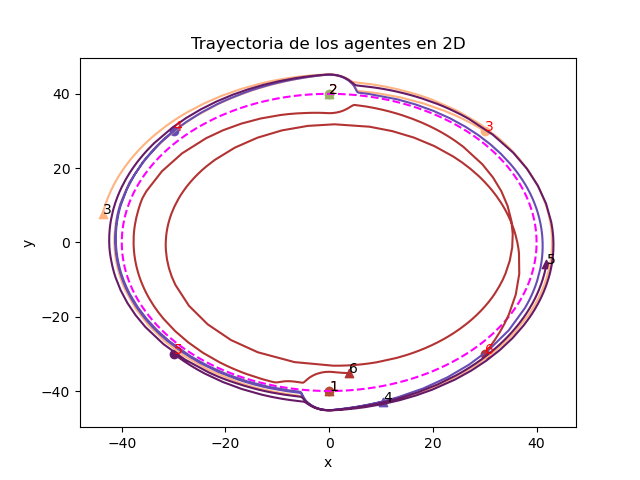

In [12]:
graph_trajectories(sol,n,N)

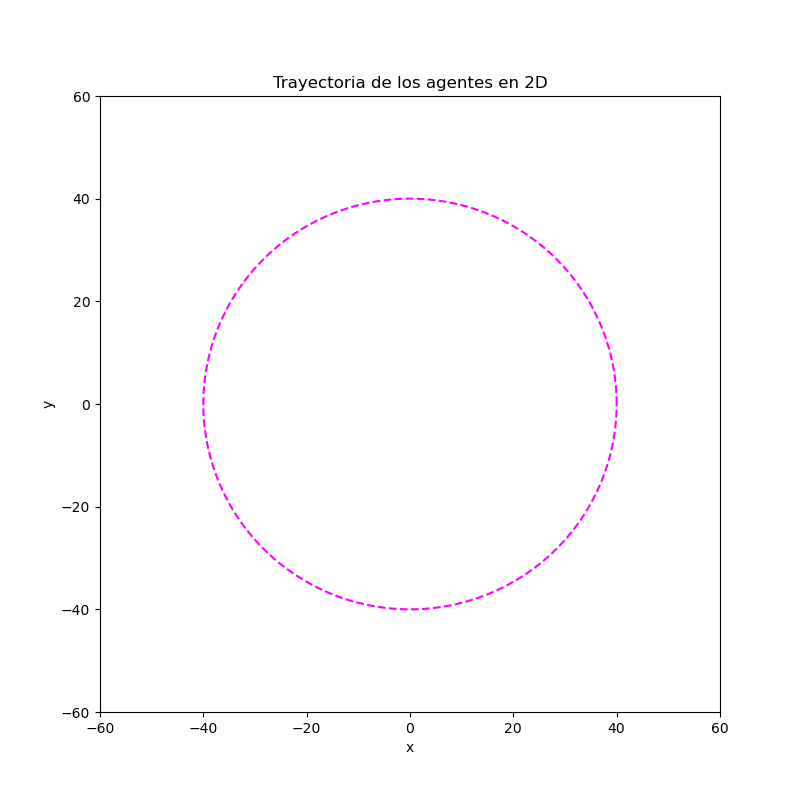

In [10]:
anim_tolerance=1   #tolerance for duplicate frames during animation
anim_limits=(-60,60)   #Plot limits for animation


animate_trajectories(sol,n,N,anim_tolerance,anim_limits)

### REPRESENTACIÓN GRÁFICA DEL CAMPO 
1 - campo vectorial para uno de los puntos solo teniendo en cuenta la separación con la trayectoria

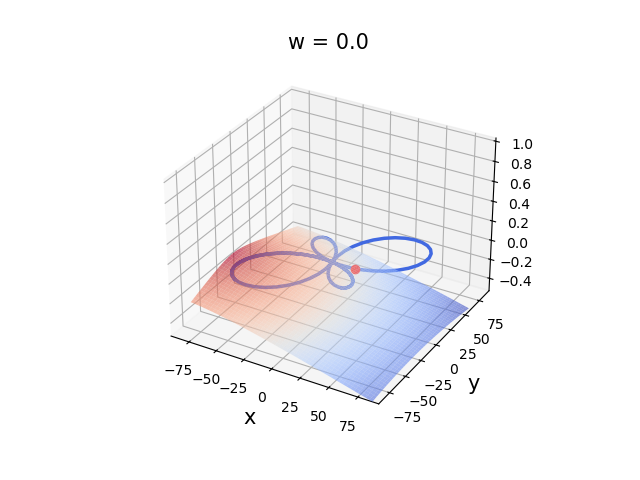

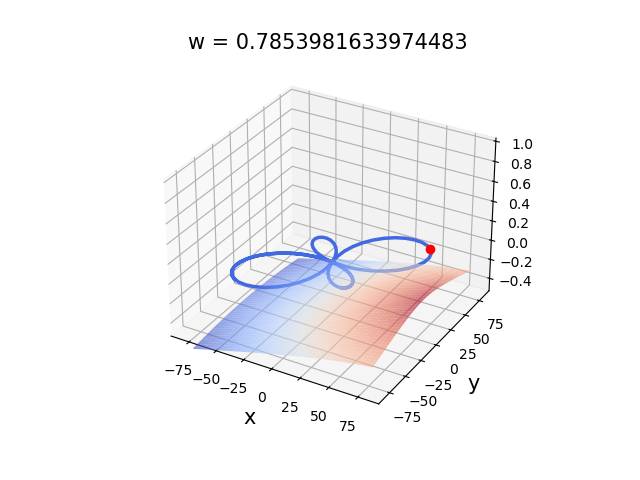

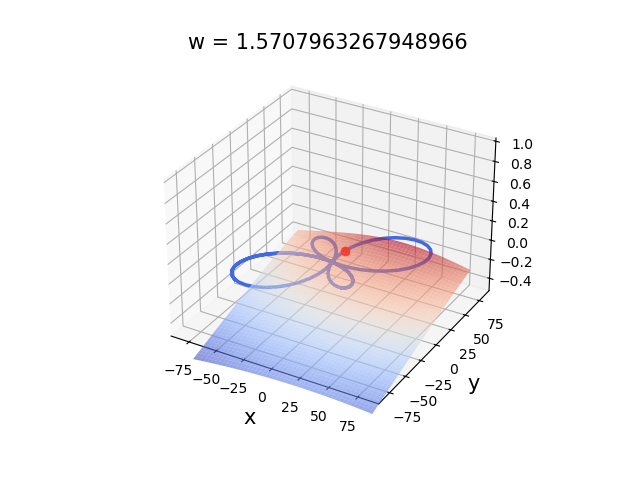

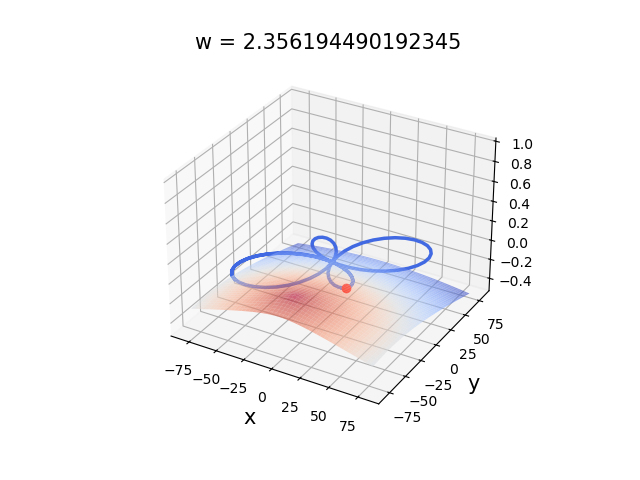

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def fun_vel_flor(xm,ym,w, radius=20, modulation=2, m=2):
    # Fórmula paramétrica para una flor de 6 pétalos
    r = radius * (1 + modulation * np.sin(m * w))  # Modulación para generar los pétalos
    x = xm - r * np.cos(w)  # Velocidad coordenada x
    y = ym - r * np.sin(w)  # Velocidad coordenada y

    return np.array([x, y])


def fun_vel_lemniscata(xm,ym,w,a,b):
    fx =xm - (a*np.cos(w) / (1 + np.sin(w)**2))  # Coordenada X
    fy =ym - (b*np.sin(w) * np.cos(w) / (1 + np.sin(w)**2))  # Coordenada Y
    return np.array([fx, fy])

def fun_ac_lemniscata(w, a, b):
    sin_w = np.sin(w)
    cos_w = np.cos(w)
    sin2_w = sin_w**2
    cos2_w = cos_w**2
    denom = (1 + sin2_w)**2

    # Derivada de x(w)
    dx_dw = (-a * sin_w * (1 + sin2_w) - a * cos_w * (2 * sin_w * cos_w)) / denom

    # Derivada de y(w)
    numerator_y = b * (cos2_w - sin2_w) * (1 + sin2_w) - b * sin_w * cos_w * (2 * sin_w * cos_w)
    dy_dw = numerator_y / denom

    return np.array([dx_dw, dy_dw])


def fun_ac_flor(w, radius=20, modulation=2, m=2):
    # Fórmula paramétrica para una flor de 6 pétalos
    r = radius * (1 + modulation * np.sin(m * w))  # Modulación para generar los pétalos
    dr=radius*modulation*m*np.cos(m*w)
    x = - dr * np.cos(w) + r * np.sin(w) # Aceleración coordenada x
    y = - dr * np.sin(w) - r * np.cos(w) # Aceleración coordenada y

    return np.array([x, y])


puntos = np.arange(-80,81,0.1)   #Grid de flechas
valores = np.linspace(-4,4,100)    #Valores de w para la trayectoria

#[f_x,f_y]=lemniscata(valores,40,80)
[f_x,f_y]=flor_2m_petalos(valores,20,3,2)

[xm,ym] = np.meshgrid(puntos,puntos)
Z=np.zeros_like(xm)

for w in np.arange(0,np.pi,np.pi/4):
    #[vx,vy]=fun_vel_lemniscata(xm,ym,w,40,80)
    #[acx,acy]=fun_ac_lemniscata(w,40,80)
    #[fw_x,fw_y]=lemniscata(w,40,80)

    [vx,vy]=fun_vel_flor(xm,ym,w,20,3,2)
    [acx,acy]=fun_ac_flor(w,20,3,2)
    [fw_x,fw_y]=flor_2m_petalos(w,20,3,2)

    U = (-vx+acx)
    V = (-vy+acy)

    # To Normalize the arrows:
    #U = U / np.sqrt(U**2 + V**2);
    #V = V / np.sqrt(U**2 + V**2);   

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    #Para la lemniscata
    #ax.plot_surface(xm, ym,np.sqrt(U**2 + V**2)/200 -0.5, cmap='coolwarm', edgecolor='none', alpha=0.6)

    #Para la flor
    ax.plot_surface(xm, ym,-np.sqrt(U**2 + V**2)/300, cmap='coolwarm', edgecolor='none', alpha=0.6)

    ax.plot(f_x,f_y,color="royalblue",linewidth = 2.5)  #Trayectoria a seguir
    ax.scatter(fw_x,fw_y,color = "red",linewidth = 2.5, zorder = 3)   #El agente sobre el que se pintan los campos

    #ax.quiver(xm,ym,0,U,V,0,color = "y")
    ax.set_title('w = '+str(w),  fontsize = 15)
    ax.set_xlabel("x", fontsize = 15)
    ax.set_ylabel("y", fontsize = 15)
    ax.set_zlim((-0.5,1))

Animar trayectorias con campo simple 

In [14]:
def animate_trajectories_simpleField(sol, n, N, tolerance, limits):
    """
    Crea una animación de las trayectorias de los agentes en 2D o 3D según la dimensión n,
    eliminando fotogramas repetidos y fijando las dimensiones de los ejes.
    
    :param sol: Resultado de la simulación que contiene las trayectorias de los robots.
    :param n: Dimensiones del espacio (2 o 3).
    :param N: Número de agentes.
    :param tolerance: Tolerancia para identificar fotogramas repetidos.
    :param limits: Límite fijo para los ejes (mínimo y máximo).
    """
    # Definir los índices de los robots
    lista = np.arange(0, (n+1)*N+1, (n+1))

    # Crear la figura
    fig = plt.figure()
    if n == 2:
        ax = fig.add_subplot()  # 2D
        w = np.linspace(0, 2 * np.pi, 1000)  # Valores del parámetro w para la lemniscata
        [f_x,f_y]=fun(w)
        ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Trayectoria de los agentes en 2D')

    elif n == 3:
        ax = fig.add_subplot(projection='3d')  # 3D
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_zlim(limits)  # Límites fijos para z
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title('Trayectoria de los agentes en 3D')

    # Generar colores aleatorios para cada robot
    if N==3:
        colors=[[1,0,0],[0,1,0],[0,0,1]]
    elif N==4:
        colors=[[1,0,0],[0,1,0],[0,0,1],[0,0,0]]
    elif N==6:
        colors=[[1,0,0],[0,1,0],[0,0,1],[1,1,0],[0,1,1],[1,0,1]]
    else:
        colors = [np.random.rand(3).tolist() for _ in range(N)]

    # Identificar los fotogramas únicos
    unique_frames = [0]  # Siempre incluimos el primer fotograma
    for frame in range(1, len(sol.t)):
        max_diff = np.max(np.abs(sol.y[:, frame] - sol.y[:, unique_frames[-1]]))
        if max_diff > tolerance:
            unique_frames.append(frame)

    
    # Función de actualización para la animación
    def update(frame_index):
        frame = unique_frames[frame_index]  # Usamos solo los fotogramas únicos

        l=len(sol.y[1,:])
        l2=len(unique_frames)
        set_arrow=1

        if set_arrow:
            if frame_index+1 < l2-1:
                frame2=unique_frames[frame_index+1] #tomo el siguiente para imprimnir la flecha
        ax.clear()  # Limpia la figura en cada frame

        if n == 2:
            # Redibujar la lemniscata en cada frame
            ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_title(f'Trayectoria de los agentes en 2D - Tiempo: {sol.t[frame]:.2f}s')

        elif n == 3:
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_zlim(limits)  # Límites fijos para z
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_zlabel('z')
            ax.set_title(f'Trayectoria de los agentes en 3D - Tiempo: {sol.t[frame]:.2f}s')

        # Dibujar trayectorias y posiciones actuales
        count = 1
        for i, color in zip(lista[:-1], colors):
            x = sol.y[i, max(0,frame-10):frame]
            y = sol.y[i+1, max(0,frame-10):frame]
            if set_arrow:
                if frame_index+1 < l2-1:
                    if frame2 <= l:
                        x2=sol.y[i,frame2]
                        y2=sol.y[i+1,frame2]

                        [vx,vy]=fun_vel_flor(xm,ym,sol.y[i+2,frame],20,3,2)
                        [acx,acy]=fun_ac_flor(sol.y[i+2,frame],20,3,2)

                        U = (vx-acx)
                        V = (vy-acy)

                        # To Normalize the arrows:
                        #U = U / np.sqrt(U**2 + V**2);
                        #V = V / np.sqrt(U**2 + V**2); 

            if len(x) > 0 and len(y) > 0:  # Validar que no estén vacíos
                if n == 2:
                    # Coordenadas para n=2
                    ax.plot(x, y, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], color=color, marker='o')  # Posición actual
                    if set_arrow:
                        if frame_index+1 < l2-1:
                            if frame2 <= l:
                                ax.quiver(xm,ym,U,V ,color = color)
                                ax.arrow(x[-1], y[-1], x2-x[-1], y2-y[-1], width=0.2,ec='black')
                    ax.text(x[-1], y[-1], str(count), color='red')
                elif n == 3:
                    # Coordenadas para n=3
                    z = sol.y[i+2, :frame]
                    #z2=sol.y[i+2,frame+1]
                    ax.plot(x, y, z, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], z[-1], color=color, marker='o')  # Posición actual
                    #if set_arrow:
                        #en el archivo de test tengo un método para imprimir flechas en 3d, pero me da pereza meterlo ahora aquí
                    x.text(x[-1], y[-1], z[-1], str(count), color='red')
            count += 1

    # Crear la animación usando solo los fotogramas únicos
    anim = FuncAnimation(fig, update, frames=len(unique_frames), interval=100)

    # Mostrar la animación
    plt.show()

    # Si deseas guardar la animación como un archivo de video:
    anim.save("trayectorias_flechas_basicField.mp4", fps=15, extra_args=['-vcodec', 'libx264'])

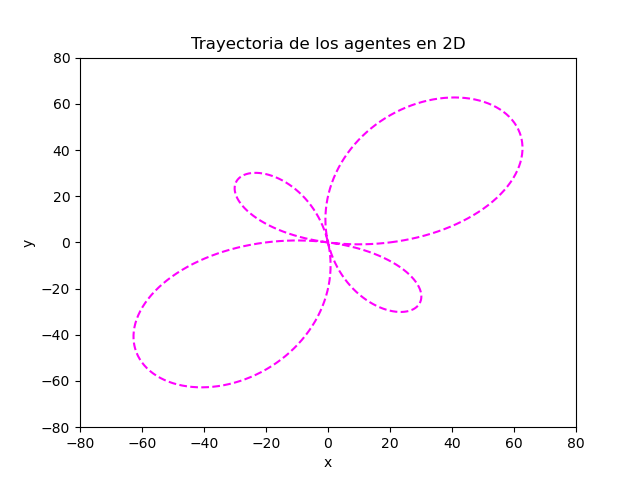

0.007830168890644076
0.006903597082124679
0.000518190369247366
0.000518190369247366
0.000518190369247366
0.000518190369247366
0.000518190369247366
0.000518190369247366
0.006191576771261044
0.000518190369247366
0.000518190369247366
0.000518190369247366
0.000518190369247366
0.000518190369247366
0.000518190369247366
0.00524035853037023
0.0005469771188073804
0.0005469771188073804
0.0005469771188073804
0.0005469771188073804
0.0005469771188073804
0.0005469771188073804
0.004429423564289195
0.0005576463534034556
0.0005576463534034556
0.0005576463534034556
0.0005576463534034556
0.0005576463534034556
0.0005576463534034556
0.0037335065221839824
0.0005732852961643341
0.0005732852961643341
0.0005732852961643341
0.0005732852961643341
0.0005732852961643341
0.0005732852961643341
0.0029383163593053644
0.0006390320038589095
0.0006390320038589095
0.0006390320038589095
0.0006390320038589095
0.0006390320038589095
0.0006390320038589095
0.0025375877136788764
0.0006944184289713833
0.0006944184289713833
0.0006

In [12]:
anim_tolerance=1   #tolerance for duplicate frames during animation
anim_limits=(-80,80)   #Plot limits for animation

n=2
N=4         #nº de agentes 

# ki =[1,1,2] #ganancias 
ki =[1,1] #ganancias 
R = 5  #Distancia de seguridad 
alpha=1 #coeficiente de convergencia de potencial de separación

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots

pos = np.random.randint(-50, 51, size=(N, n)) 

#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta = T/N
kc = 300

ww = np.zeros(N)
for i in range(N):
    ww[i] = i*Delta

sol = sl(vector_field, (0,10),Xi[0],method='LSODA',args=(ki,n,N,ww,kc,L),max_step=0.2) 
animate_trajectories_simpleField(sol, n, N, anim_tolerance, anim_limits)

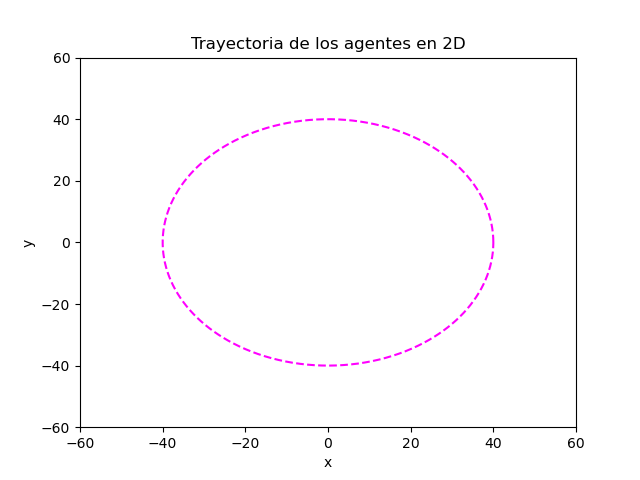

KeyboardInterrupt: 

In [17]:
anim_tolerance=1 
anim_limits=(-60,60)

animate_trajectories_simpleField(sol,n, N, anim_tolerance, anim_limits)

In [13]:
def animate_trajectories_simpleField_surf(sol, n, N, tolerance, limits, agente):
    """
    Crea una animación de las trayectorias de los agentes en 2D o 3D según la dimensión n,
    eliminando fotogramas repetidos y fijando las dimensiones de los ejes.
    
    :param sol: Resultado de la simulación que contiene las trayectorias de los robots.
    :param n: Dimensiones del espacio (2 o 3).
    :param N: Número de agentes.
    :param tolerance: Tolerancia para identificar fotogramas repetidos.
    :param limits: Límite fijo para los ejes (mínimo y máximo).
    """
    # Definir los índices de los robots
    lista = np.arange(0, (n+1)*N+1, (n+1))

    # Crear la figura
    fig = plt.figure()
    if n == 2:
        ax = fig.add_subplot(projection='3d')  # 2D representada en un plot 3d para ver la superficie
        w = np.linspace(0, 2 * np.pi, 1000)  # Valores del parámetro w para la lemniscata
        [f_x,f_y]=fun(w)
        ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Trayectoria de los agentes en 2D')

    # Generar colores aleatorios para cada robot
    if N==3:
        colors=[[1,0,0],[0,1,0],[0,0,1]]
    elif N==4:
        colors=[[1,0,0],[0,1,0],[0,0,1],[0,0,0]]
    elif N==6:
        colors=[[1,0,0],[0,1,0],[0,0,1],[1,1,0],[0,1,1],[1,0,1]]
    else:
        colors = [np.random.rand(3).tolist() for _ in range(N)]

    # Identificar los fotogramas únicos
    unique_frames = [0]  # Siempre incluimos el primer fotograma
    for frame in range(1, len(sol.t)):
        max_diff = np.max(np.abs(sol.y[:, frame] - sol.y[:, unique_frames[-1]]))
        if max_diff > tolerance:
            unique_frames.append(frame)

    
    # Función de actualización para la animación
    def update(frame_index):
        frame = unique_frames[frame_index]  # Usamos solo los fotogramas únicos

        l=len(sol.y[1,:])
        l2=len(unique_frames)
        set_arrow=1

        if set_arrow:
            if frame_index+1 < l2-1:
                frame2=unique_frames[frame_index+1] #tomo el siguiente para imprimnir la flecha
        ax.clear()  # Limpia la figura en cada frame

        if n == 2:
            # Redibujar la lemniscata en cada frame
            ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_title(f'Trayectoria de los agentes en 2D - Tiempo: {sol.t[frame]:.2f}s')

        # Dibujar trayectorias y posiciones actuales
        count = 1
        for i, color in zip(lista[:-1], colors):
            x = sol.y[i, max(0,frame-10):frame]
            y = sol.y[i+1, max(0,frame-10):frame]
            if set_arrow:
                if frame_index+1 < l2-1:
                    if frame2 <= l:
                        x2=sol.y[i,frame2]
                        y2=sol.y[i+1,frame2]

                        [vx,vy]=fun_vel_flor(xm,ym,sol.y[i+2,frame2],20,3,2)
                        [acx,acy]=fun_ac_flor(sol.y[i+2,frame2],20,3,2)

                        U = (vx-acx)
                        V = (vy-acy)

                        # To Normalize the arrows:
                        #U = U / np.sqrt(U**2 + V**2);
                        #V = V / np.sqrt(U**2 + V**2); 

            if len(x) > 0 and len(y) > 0:  # Validar que no estén vacíos
                if n == 2:
                    # Coordenadas para n=2
                    ax.plot(x, y, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], color=color, marker='o')  # Posición actual
                    if set_arrow:
                        if frame_index+1 < l2-1:
                            if frame2 <= l:
                                if i == agente:
                                    ax.plot_surface(xm, ym,-(np.sqrt(U**2 + V**2)/200)  , cmap='coolwarm', edgecolor='none', alpha=0.8)
                                #ax.quiver(xm,ym,U,V ,color = color)
                                #ax.arrow(x[-1], y[-1], x2-x[-1], y2-y[-1], width=0.2,ec='black')
                    ax.text(x[-1], y[-1],0, str(count), color='red')
            count += 1

    # Crear la animación usando solo los fotogramas únicos
    anim = FuncAnimation(fig, update, frames=len(unique_frames), interval=100)

    # Mostrar la animación
    plt.show()

    # Si deseas guardar la animación como un archivo de video:
    anim.save("trayectorias_flechas_basicField_surf.mp4", fps=15, extra_args=['-vcodec', 'libx264'])

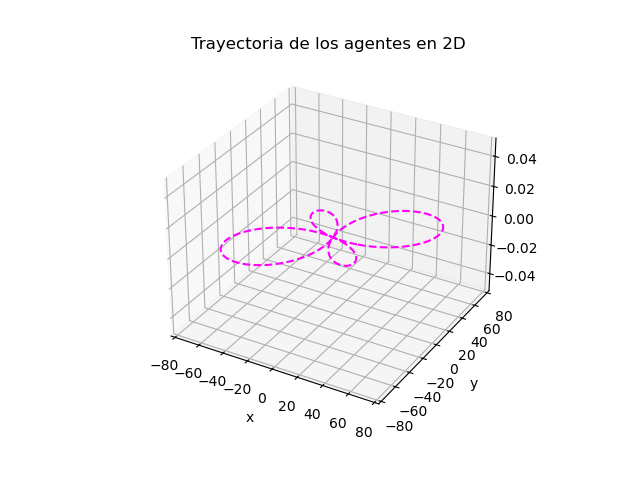

0.0014215564404727347
0.0014215564404727347
0.0003420233629372948
0.0003420233629372948
0.0003420233629372948
0.0003420233629372948
0.0003420233629372948
0.0003420233629372948
0.0002487293513110033
0.004249062953611729
0.004249062953611729
0.0002288327905970761
0.0027886446984433976
0.0027886446984433976
0.0027886446984433976
0.0027886446984433976
0.0027886446984433976
0.0027886446984433976
0.0002400997366459333
0.0020854527038611315
0.0020854527038611315
0.0020854527038611315
0.0020854527038611315
0.0020854527038611315
0.0020854527038611315
0.0002524056895999095
0.00025629645126991633
0.0002437062209153179
0.0023015384560675597
0.027057393897098277
0.027057393897098277
0.027057393897098277
0.027057393897098277
0.027057393897098277
0.027057393897098277
0.0030828908224134616
0.009026243966287366
0.009026243966287366
0.009026243966287366
0.009026243966287366
0.009026243966287366
0.009026243966287366
0.003952782905534319
0.006501011563993958
0.006501011563993958
0.006501011563993958
0.006

In [14]:
anim_tolerance=1   #tolerance for duplicate frames during animation
anim_limits=(-80,80)   #Plot limits for animation

n=2
N=4         #nº de agentes 

# ki =[1,1,2] #ganancias 
ki =[1,1] #ganancias 
R = 5  #Distancia de seguridad 
alpha=1 #coeficiente de convergencia de potencial de separación

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots

pos = np.random.randint(-50, 51, size=(N, n)) 

#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta = T/N
kc = 300

ww = np.zeros(N)
for i in range(N):
    ww[i] = i*Delta

sol = sl(vector_field, (0,10),Xi[0],method='LSODA',args=(ki,n,N,ww,kc,L),max_step=0.2) 
animate_trajectories_simpleField_surf(sol, n, N, anim_tolerance, anim_limits,0)

In [72]:
from mpl_toolkits import mplot3d

def animate_trajectories_barrier_surf(sol, n, N, tolerance, limits,limitsz, agente):
    """
    Crea una animación de las trayectorias de los agentes en 2D o 3D según la dimensión n,
    eliminando fotogramas repetidos y fijando las dimensiones de los ejes.
    
    :param sol: Resultado de la simulación que contiene las trayectorias de los robots.
    :param n: Dimensiones del espacio (2 o 3).
    :param N: Número de agentes.
    :param tolerance: Tolerancia para identificar fotogramas repetidos.
    :param limits: Límite fijo para los ejes (mínimo y máximo).
    """
    # Definir los índices de los robots
    lista = np.arange(0, (n+1)*N+1, (n+1))
    

    # Crear la figura
    fig = plt.figure()
    if n == 2:
        ax = fig.add_subplot(projection='3d')  # 2D representada en un plot 3d para ver la superficie
        w = np.linspace(0, 2 * np.pi, 1000)  # Valores del parámetro w para la lemniscata
        [f_x,f_y]=fun(w)
        ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_zlim(limitsz)  # Límites fijos para y     
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('y')
        ax.set_title('Trayectoria de los agentes en 2D')

    # Generar colores aleatorios para cada robot
    if N==3:
        colors=[[1,0,0],[0,1,0],[0,0,1]]
    elif N==4:
        colors=[[1,0,0],[0,1,0],[0,0,1],[0,0,0]]
    elif N==6:
        colors=[[1,0,0],[0,1,0],[0,0,1],[1,1,0],[0,1,1],[1,0,1]]
    else:
        colors = [np.random.rand(3).tolist() for _ in range(N)]

    # Identificar los fotogramas únicos
    unique_frames = [0]  # Siempre incluimos el primer fotograma
    for frame in range(1, len(sol.t)):
        max_diff = np.max(np.abs(sol.y[:, frame] - sol.y[:, unique_frames[-1]]))
        if max_diff > tolerance:
            unique_frames.append(frame)

    
    def distancias_puntos(xp,yp,x,y):
        d=np.sqrt((xp-x)**2 + (yp-y)**2)
        for i in range(len(xp[1,:])):
            for j in range(len(xp[:,1])):
                
                if d[j,i]<1:
                    d[j,i]=1
                d[j,i]=1/d[j,i]

        return d

    def distancias_puntos_h(xp,yp,x,y):
        return ((np.sqrt((xp-x)**2 + (yp-y)**2))**2 - R**2)/(2*R)
    

    # Función de actualización para la animación
    def update(frame_index):
        frame = unique_frames[frame_index]  # Usamos solo los fotogramas únicos

        l=len(sol.y[1,:])
        l2=len(unique_frames)
        set_arrow=1

        if set_arrow:
            if frame_index+1 < l2-1:
                frame2=unique_frames[frame_index+1] #tomo el siguiente para imprimnir la flecha
                frame0=unique_frames[frame_index-1]
        ax.clear()  # Limpia la figura en cada frame

        if n == 2:
            # Redibujar la lemniscata en cada frame
            ax.plot(f_x, f_y,0, color='magenta', linestyle='--', label='Lemniscata')
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_zlim(limitsz)  # Límites fijos para y   
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_zlabel('y')
            ax.set_title(f'Trayectoria de los agentes en 2D - Tiempo: {sol.t[frame]:.2f}s')

        # Dibujar trayectorias y posiciones actuales
        count = 1
        for i, color in zip(lista[:-1], colors):

            x = sol.y[i, max(0,frame-10):frame]
            y = sol.y[i+1, max(0,frame-10):frame]


            if set_arrow:
                if frame_index+1 < l2-1:
                    if frame2 <= l:
                        #x2=sol.y[i,frame2]
                        #y2=sol.y[i+1,frame2]

                        [vx,vy]=fun_vel_flor(xm,ym,sol.y[i+2,frame],20,3,2)
                        [acx,acy]=fun_ac_flor(sol.y[i+2,frame],20,3,2)

                        U = (vx-acx)
                        V = (vy-acy)

                        # To Normalize the arrows:
                        #U = U / np.sqrt(U**2 + V**2);
                        #V = V / np.sqrt(U**2 + V**2); 

                        zm=np.zeros_like(xm,dtype=float)

                        #pintar barrera
                        for j in (j for j in range(N) if j != agente):
                            #Z=np.zeros_like(xm,dtype=float)
                            if np.sqrt((sol.y[3*agente,frame]-sol.y[3*j,frame])**2 + (sol.y[3*agente+1,frame]-sol.y[3*j+1,frame])**2)<=50*R:   
                                Z=distancias_puntos(xm,ym,float(sol.y[3*j,frame0]),float(sol.y[3*j+1,frame0]))  
                                Z=Z*1/distancias_puntos_h(sol.y[3*agente,frame0],sol.y[3*agente+1,frame0],sol.y[3*j,frame0],sol.y[3*j+1,frame0])
                                #Z=Z/np.max(Z)
                                zm+=Z
                        #zm=zm/np.max(zm)
                                
            if len(x) > 0 and len(y) > 0:  # Validar que no estén vacíos
                if n == 2:
                    # Coordenadas para n=2
                    ax.plot(x, y,0, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], color=color, marker='o')  # Posición actual
                    ax.plot([x[-1],x[-1]], [y[-1],y[-1]],[-1.5,0.5], color=color)
                    if set_arrow:
                        if frame_index+1 < l2-1:
                            if frame2 <= l:
                                if i == agente:
                                    ax.plot_surface(xm, ym,(zm/3-(np.sqrt(U**2 + V**2)/np.max(np.sqrt(U**2 + V**2))))-0.5  , cmap='coolwarm', edgecolor='none', alpha=0.8)
                                    #ax.plot_surface(xm, ym,(zm, cmap='coolwarm', edgecolor='none', alpha=0.8)
                                #ax.quiver(xm,ym,U,V ,color = color)
                                #ax.arrow(x[-1], y[-1], x2-x[-1], y2-y[-1], width=0.2,ec='black')
                    ax.text(x[-1], y[-1],0, str(count), color='red')
            count += 1

    # Crear la animación usando solo los fotogramas únicos
    anim = FuncAnimation(fig, update, frames=len(unique_frames), interval=100)

    # Mostrar la animación
    plt.show()

    # Si deseas guardar la animación como un archivo de video:
    anim.save("trayectorias_barrier_surf.mp4", fps=15, extra_args=['-vcodec', 'libx264'])

In [65]:
anim_tolerance=2   #tolerance for duplicate frames during animation
anim_limits=(-80,80)   #Plot limits for animation
anim_limits_z=(-1.5,0.5)

n=2
N=6         #nº de agentes 

# ki =[1,1,2] #ganancias 
ki =[1,1] #ganancias 
R = 5  #Distancia de seguridad 
alpha=1 #coeficiente de convergencia de potencial de separación

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots

pos = np.random.randint(-50, 51, size=(N, n)) 

#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta = T/N
kc = 300

ww = np.zeros(N)
for i in range(N):
    ww[i] = i*Delta
                               

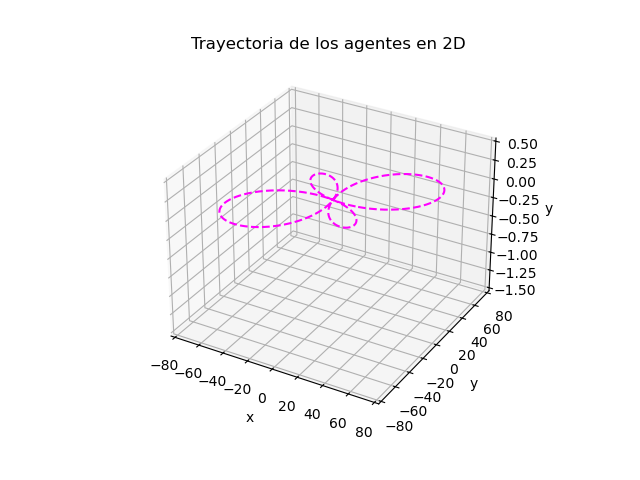

0.0029866316846310402
0.0014215564404727347
0.0014215564404727347
0.0014215564404727347
0.0014215564404727347
0.0014215564404727347
0.0014215564404727347
0.006738332333203797
0.0017089764460955666
0.0017089764460955666
0.0017089764460955666
0.0017089764460955666
0.0017089764460955666
0.0017089764460955666
0.03419098793758482
0.0019396918030237771
0.0019396918030237771
0.0019396918030237771
0.0019396918030237771
0.2289640363585137
0.010722752272741163
0.03278489868084282
0.03278489868084282
0.03278489868084282
0.03278489868084282
0.03278489868084282
0.03278489868084282
0.001315608164364674
0.006738332333203797
0.006738332333203797
0.006738332333203797
0.006738332333203797
0.006738332333203797
0.006738332333203797
0.0010407266844465418
0.03419098793758482
0.03419098793758482
0.03419098793758482
0.03419098793758482
0.03419098793758482
0.03419098793758482
0.0012228977222680168
0.2289640363585137
0.2289640363585137
0.2289640363585137
0.2289640363585137
0.2289640363585137
0.2289640363585137


In [69]:
sol = sl(safe_vector_field, (0,10),Xi[0],method='LSODA',args=(R,ki,n,N,ww,kc,L,alpha),max_step=0.2) 


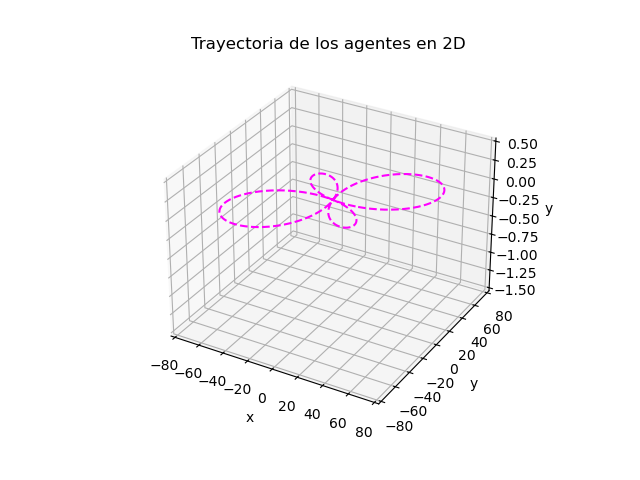

0.0008075628170043997
0.0024401276780129937
0.0024401276780129937
0.0024401276780129937
0.0024401276780129937
0.0024401276780129937
0.0024401276780129937
0.0029202963909394234
0.0028219768902615974
0.0002458685055747043
0.0002458685055747043
0.0002458685055747043
0.0002458685055747043
0.00023383812785137678
0.00023383812785137678
0.0025570138884268225
0.00147905509309704
0.00024904355151817895
0.00024904355151817895
0.00024904355151817895
0.00024904355151817895
0.00024904355151817895
0.00024904355151817895
0.001205309131328499
0.0002590144292085563
0.0002590144292085563
0.0002590144292085563
0.0002590144292085563
0.001094067967611189
0.001094067967611189
0.001094067967611189
0.001094067967611189
0.001094067967611189
0.001094067967611189
0.0005058478091831085
0.0012143493768345568
0.0012143493768345568
0.0012143493768345568
0.0012143493768345568
0.0012143493768345568
0.0012143493768345568
0.0005171327637753347
0.0013288156827519313
0.0013288156827519313
0.0013288156827519313
0.001328815

In [73]:
animate_trajectories_barrier_surf(sol, n, N, anim_tolerance, anim_limits,anim_limits_z,0)

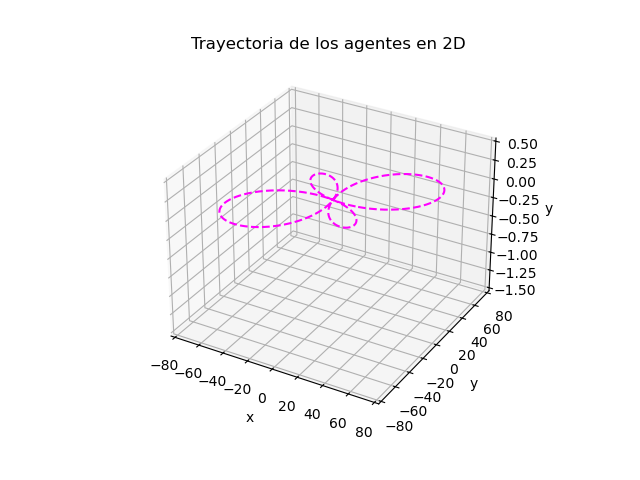

0.03324217754982888
0.03324217754982888
0.03324217754982888
0.03324217754982888
0.0003723352374073259
0.0003723352374073259
0.0003723352374073259
0.0003723352374073259
0.0003723352374073259
0.0003723352374073259


In [19]:
from mpl_toolkits import mplot3d

def animate_trajectories_barrier_surf_sep(sol, n, N, tolerance, limits,limitsz, agente):
    """
    Crea una animación de las trayectorias de los agentes en 2D o 3D según la dimensión n,
    eliminando fotogramas repetidos y fijando las dimensiones de los ejes.
    
    :param sol: Resultado de la simulación que contiene las trayectorias de los robots.
    :param n: Dimensiones del espacio (2 o 3).
    :param N: Número de agentes.
    :param tolerance: Tolerancia para identificar fotogramas repetidos.
    :param limits: Límite fijo para los ejes (mínimo y máximo).
    """
    # Definir los índices de los robots
    lista = np.arange(0, (n+1)*N+1, (n+1))
    

    # Crear la figura
    fig = plt.figure(figsize=(12,12))
    if n == 2:
        ax = fig.add_subplot(projection='3d')  # 2D representada en un plot 3d para ver la superficie
        w = np.linspace(0, 2 * np.pi, 1000)  # Valores del parámetro w para la lemniscata
        [f_x,f_y]=fun(w)
        ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_zlim(limitsz)  # Límites fijos para y     
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('y')
        ax.set_title('Trayectoria de los agentes en 2D')

    # Generar colores aleatorios para cada robot
    if N==3:
        colors=[[1,0,0],[0,1,0],[0,0,1]]
    elif N==4:
        colors=[[1,0,0],[0,1,0],[0,0,1],[0,0,0]]
    elif N==6:
        colors=[[1,0,0],[0,1,0],[0,0,1],[1,1,0],[0,1,1],[1,0,1]]
    else:
        colors = [np.random.rand(3).tolist() for _ in range(N)]

    # Identificar los fotogramas únicos
    unique_frames = [0]  # Siempre incluimos el primer fotograma
    for frame in range(1, len(sol.t)):
        max_diff = np.max(np.abs(sol.y[:, frame] - sol.y[:, unique_frames[-1]]))
        if max_diff > tolerance:
            unique_frames.append(frame)

    
    def distancias_puntos(xp,yp,x,y):
        d=np.sqrt((xp-x)**2 + (yp-y)**2)
        for i in range(len(xp[1,:])):
            for j in range(len(xp[:,1])):
                
                if d[j,i]<1:
                    d[j,i]=1
                d[j,i]=1/d[j,i]

        return d

    def distancias_puntos_h(xp,yp,x,y):
        return ((np.sqrt((xp-x)**2 + (yp-y)**2))**2 - R**2)/(2*R)
    

    # Función de actualización para la animación
    def update(frame_index):
        frame = unique_frames[frame_index]  # Usamos solo los fotogramas únicos

        l=len(sol.y[1,:])
        l2=len(unique_frames)
        set_arrow=1

        if set_arrow:
            if frame_index+1 < l2-1:
                frame2=unique_frames[frame_index+1] #tomo el siguiente para imprimnir la flecha
                frame0=unique_frames[frame_index-1]
        ax.clear()  # Limpia la figura en cada frame

        if n == 2:
            # Redibujar la lemniscata en cada frame
            ax.plot(f_x, f_y,0, color='magenta', linestyle='--', label='Lemniscata')
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_zlim(limitsz)  # Límites fijos para y   
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_zlabel('y')
            ax.set_title(f'Trayectoria de los agentes en 2D - Tiempo: {sol.t[frame]:.2f}s')

        # Dibujar trayectorias y posiciones actuales
        count = 1
        for i, color in zip(lista[:-1], colors):

            x = sol.y[i, max(0,frame-10):frame]
            y = sol.y[i+1, max(0,frame-10):frame]


            if set_arrow:
                if frame_index+1 < l2-1:
                    if frame2 <= l:
                        #x2=sol.y[i,frame2]
                        #y2=sol.y[i+1,frame2]

                        [vx,vy]=fun_vel_lemniscata(xm,ym,sol.y[i+2,frame],40,80)
                        [acx,acy]=fun_ac_lemniscata(sol.y[i+2,frame],40,80)

                        U = (vx-acx)
                        V = (vy-acy)

                        # To Normalize the arrows:
                        #U = U / np.sqrt(U**2 + V**2);
                        #V = V / np.sqrt(U**2 + V**2); 

                        zm=np.zeros_like(xm,dtype=float)

                        #pintar barrera
                        for j in (j for j in range(N) if j != agente):
                            #Z=np.zeros_like(xm,dtype=float)
                            if np.sqrt((sol.y[3*agente,frame]-sol.y[3*j,frame])**2 + (sol.y[3*agente+1,frame]-sol.y[3*j+1,frame])**2)<=50*R:   
                                Z=distancias_puntos(xm,ym,float(sol.y[3*j,frame0]),float(sol.y[3*j+1,frame0]))  
                                Z=Z*1/distancias_puntos_h(sol.y[3*agente,frame0],sol.y[3*agente+1,frame0],sol.y[3*j,frame0],sol.y[3*j+1,frame0])
                                #Z=Z/np.max(Z)
                                zm+=Z
                        #zm=zm/np.max(zm)
                                
            if len(x) > 0 and len(y) > 0:  # Validar que no estén vacíos
                if n == 2:
                    # Coordenadas para n=2
                    ax.plot(x, y,0, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], color=color, marker='o')  # Posición actual
                    ax.plot([x[-1],x[-1]], [y[-1],y[-1]],[-1.5,0.5], color=color)
                    if set_arrow:
                        if frame_index+1 < l2-1:
                            if frame2 <= l:
                                if i == agente:
                                    ax.plot_surface(xm, ym,((np.sqrt(U**2 + V**2)/np.max(np.sqrt(U**2 + V**2))))-0.5 , cmap='coolwarm', edgecolor='none', alpha=0.6)
                                    ax.plot_surface(xm, ym,zm/3 -1 , cmap='coolwarm', edgecolor='none', alpha=0.8)
                                    #ax.plot_surface(xm, ym,(zm, cmap='coolwarm', edgecolor='none', alpha=0.8)
                                #ax.quiver(xm,ym,U,V ,color = color)
                                #ax.arrow(x[-1], y[-1], x2-x[-1], y2-y[-1], width=0.2,ec='black')
                    ax.text(x[-1], y[-1],0, str(count), color='red')
            count += 1

    # Crear la animación usando solo los fotogramas únicos
    anim = FuncAnimation(fig, update, frames=len(unique_frames), interval=100)

    # Mostrar la animación
    plt.show()

    # Si deseas guardar la animación como un archivo de video:
    anim.save("trayectorias_barrier_surf.mp4", fps=15, extra_args=['-vcodec', 'libx264'])

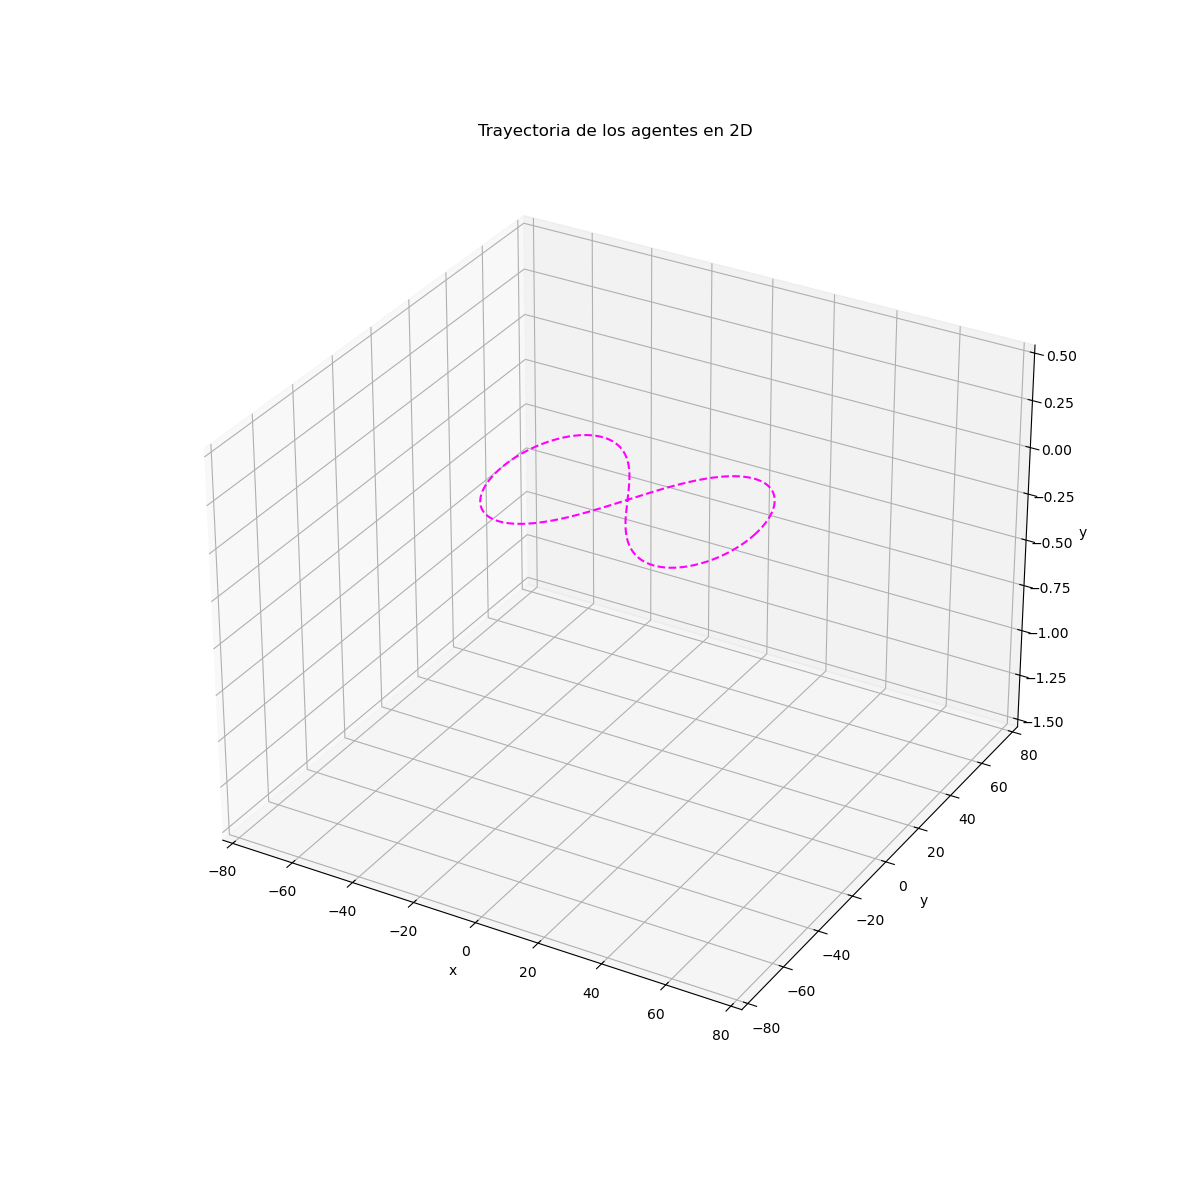

In [30]:
anim_tolerance=2   #tolerance for duplicate frames during animation
anim_limits=(-80,80)   #Plot limits for animation
anim_limits_z=(-1.5,0.5)

n=2
N=4         #nº de agentes 

# ki =[1,1,2] #ganancias 
ki =[1,1] #ganancias 
R = 10  #Distancia de seguridad 
alpha=1 #coeficiente de convergencia de potencial de separación

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots

pos = np.random.randint(-50, 51, size=(N, n)) 

#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta = T/N
kc = 300

ww = np.zeros(N)
for i in range(N):
    ww[i] = i*Delta

sol = sl(safe_vector_field, (0,10),Xi[0],method='LSODA',args=(R,ki,n,N,ww,kc,L,alpha),max_step=0.2)               
animate_trajectories_barrier_surf_sep(sol, n, N, anim_tolerance, anim_limits,anim_limits_z,0)

/var/folders/z7/7fzwy2zj1h500lg01l_r8r1c0000gn/T/ipykernel_2268/735549514.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12,12))


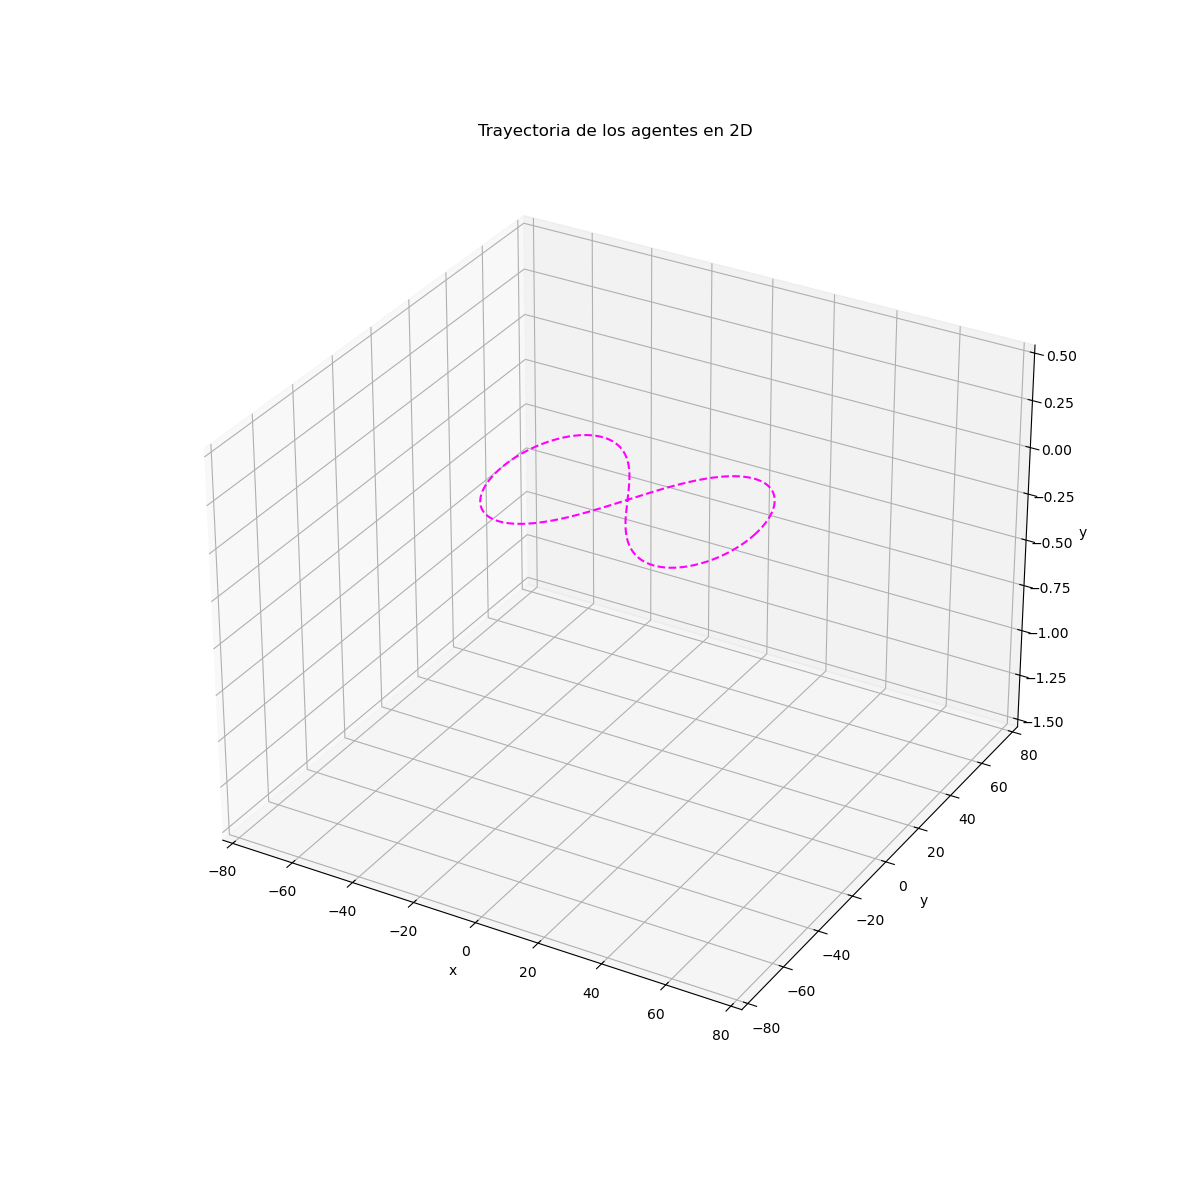

In [21]:
animate_trajectories_barrier_surf_sep(sol, n, N, anim_tolerance, anim_limits,anim_limits_z,0)

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Feb  5 12:08:19 2025

@author: lia

GVF +CBF segun la tesis de Weija para evitar choques entre robots
Version inicial para 3 agentes que se comunican todos entre sí en 2D

"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import qp as qp
import graph_utils as gu
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import solve

#CASO DE 3 ROBOTS EN UN ESPACIO 2-DIMENSIONAL

#todos los agentes siguen las mismas ecuaciones de trayectoria

np.random.seed(123)

#Definimos en una función las ecuaciones de la trayectoria 

def fun(w):
    f1 = 15*np.sin(2*w)
    f2 = 30*np.sin(w)*(np.sqrt(0.5*(1-0.5*(np.sin(w))**2)))
    f3 = 3+5*np.cos(2*w)
    return np.array([f1, f2])

#funciones phi
def phi(vec_pos):
    f = fun(vec_pos[-1])
    return vec_pos[:-1] - f

# calculamos la derivada de las ecuaciones de la trayectoria
def d_fun(w):
    #derivada central
    h = 1e-8 #paso
    df = (fun(w+h)-fun(w-h))/(2*h)
    return df

#matriz lapaciana de un grafo (los agentes están comunicados con los vecinos adyacentes)
def grafo_L(N):
    #N: nº de agentes 
    L = np.zeros([N,N])  
    
    # Llenar la diagonal con 2 
    np.fill_diagonal(L, 2)
    
    # Llenar las diagonales justo arriba y abajo de la diagonal principal con -1
    np.fill_diagonal(L[:, 1:], -1)
    np.fill_diagonal(L[1:, :], -1)
    
    # Llenar las esquinas con -1
    L[0, -1] = -1
    L[-1, 0] = -1
    
    return L

def vector_field(t,xi,k,n,N,ww,kc,L):
    #xi: posiciones de todos los agentes (vector columna con las 4 coordenadas )
    #t: tiempo
    #k: ganancias positivas
    #n: dimensiones 
    #N: nº de agentes 
    #L: matriz laplaciana de un grafo

    lista = np.arange(0,(n+1)*N+1,(n+1))
    k = k*N

    PHI = np.zeros(n*N) #lista vacía de funciones surface
    df = np.zeros(n*N)  #lista vacía de las derivadas 
    w = np.zeros(N)     #lista vacía para las coordenadas virtuales
    j = 0 
    for i in lista[:-1]: 
        x = xi[i:i+(n+1)]               #coordenada inicial + virtual de cada agente
        PHI[i-j:(i-j)+n] = phi(x)       #función surface 
        df[i-j:(i-j)+n] = d_fun(x[-1])  #derivada 
        w[j] = x[-1]                    #coordenadas virtuales 
        j += 1

    xi_eta = (-1)**n*df-k*PHI

    #sumatorio

    l = k*PHI*df
    # Convertir la matriz l en una matriz de n filas
    matriz_l = l.reshape((N, -1))
    #sumar a los largo del eje de las filas 
    suma = np.sum(matriz_l, axis=1)

    #función de coordinación 
    c = -L@np.transpose(w-ww)
    
    xi4 = (-1)**n+suma+kc*c

    #path-following guiding vector field 
    xi_eta = np.concatenate((xi_eta.reshape((N,n)),np.array([xi4]).T),axis=1)
    xi_eta = xi_eta.reshape((N*(n+1),-1)).T

    return xi_eta[0]

    #TODO: Revisar y entender bien el problema porque algo se me escapa

def vector_field_CBF_new(t,xi,n,N,R,alpha,vecinos,k,ww,kc,L):
    #xi: posiciones de todos los agentes (vector columna con las 4 coordenadas )
    #eta: campo guiado para todos los agentes
    #k: ganancias positivas
    #n: dimensiones 
    #N: nº de agentes 
    #R: distancia de seguridad entre los robots
    #alpha: ganancia de la barrera
    #vecinos: matriz con los indices de los vecinos de cada robot
    # Desapilo el campo (cuidado que lleva la coordenada ampliada)
    Chi_ap=vector_field(t,xi,k,n,N,ww,kc,L)
    Chi=gu.unstack(Chi_ap,n+1)
    # Desapilo posiciones
    pi=gu.unstack(xi,n+1)
    Chi_cbf=np.zeros((N,n+1))
    #Construyo las matrices
    M=np.eye(n+1,n+1)
    Pr=np.zeros((n+1,n+1))
    Pr[-1,-1]=1
    P=M-Pr
    eta=np.zeros((N,N))
    dx=np.zeros((N,N)) 
    dy=np.zeros((N,N)) 
    for i in range(N):
        nvecinos=len(vecinos[i,:])
        for j in range(nvecinos):
            eta[i,vecinos[i,j]]=np.linalg.norm(P@(pi[i,:]-pi[vecinos[i,j],:]))**2-R**2
            dx[i,vecinos[i,j]]=pi[i,0]-pi[vecinos[i,j],0]
            dy[i,vecinos[i,j]]=pi[i,1]-pi[vecinos[i,j],1]
    P=np.zeros((N,N-1,N-1)) 
    P=np.array([[[-dx[1,0], -dx[2,0]],[-dy[1,0],-dy[2,0]]],
                [[-dx[0,1], -dx[2,1]],[-dy[0,1],-dy[2,1]]],
                [[-dx[0,2], -dx[1,2]],[-dy[0,2],-dy[1,2]]]])
    M=np.zeros((2*n,2*n))
    Mm=np.zeros((2*n,2*n))
    agente=0
    Aj=np.zeros((1,N-1))
   
    condicion=np.zeros(N)
    for i in range(N):
        Pi=P[i,:,:]
        #Veo si el campo de seguimiento verifica la condición
        #TODO Revisar esto
        for j in range(2): #porque tiene 2 vecinos
           Aj[0,0]=dx[i,vecinos[i,j]]
           Aj[0,1]=dy[i,vecinos[i,j]]
           c1=Aj@Chi_ap[agente:agente+2]
           c2=alpha*eta[i,vecinos[i,j]]**3/4
           
           if c1[0]<=c2:
               condicion[i]=condicion[i]+1
          
        if condicion[i]==2:
            Chi_cbf[i,0:3]=Chi_ap[agente:agente+3]
            #print("Chi_pf. Agente ",i)
            agente=agente+3
        else:
            #print("CBF. Agente ",i)
            Pt=Pi.T
            Pt_inv=np.linalg.inv(Pt)
            P_inv=np.linalg.inv(Pi)
            M[0:2,2:4]=Pt_inv
            M[2:4,0:2]=P_inv
            M[2:4,2:4]=-P_inv@Pt_inv
            k=i+1
            k2=k+1
            Mm[0:2,0:2]=np.eye(2)
            Mm[0:2,2:4]=Pi
            Mm[2:4,0:2]=Pi.T
            if k==3:
                k=0
                k2=1
            elif k==2:
                k=0
                k2=2
            #if (eta[i,k]<=0) or (eta[i,k2]<=0):
            b=np.array([Chi_ap[agente],Chi_ap[agente+1],-alpha*eta[i,k]**3/4,-alpha*eta[i,k2]**3/4])  
            #S=M@b
            #Resuelvo el sistema
            S=solve(Mm,b)
            Chi_cbf[i,0:2]=S[0:2]
            dum=Chi_ap[agente+2]
            Chi_cbf[i,2]=dum
            '''  
             else: 
                Chi_cbf[i,0:2]=Chi_ap[agente:agente+2]
                dum=Chi_ap[agente+2]
                Chi_cbf[i,2]=dum
                '''
            agente=agente+3
        #Chi_cbf[i,:]=qp.qp_solve(M,-Chi[i,:],G=A,h=b,A=None,b=None,lb=None,ub=None)
       
        
    
 
        
    Chi_cbf_ap=Chi_cbf.reshape((N*(n+1),-1)).T
    #print("Chi_cbf",Chi_cbf_ap)
    #print("Chi_pf",Chi_ap)
    return Chi_cbf_ap
#TODO: Revisar porque se van todos los campos a cero

def vector_field_CBF_analitico(t,xi,n,N,R,alpha,vecinos,k,ww,kc,L):
    #xi: posiciones de todos los agentes (vector columna con las 4 coordenadas )
    #eta: campo guiado para todos los agentes
    #k: ganancias positivas
    #n: dimensiones 
    #N: nº de agentes 
    #R: distancia de seguridad entre los robots
    #alpha: ganancia de la barrera
    #vecinos: matriz con los indices de los vecinos de cada robot
    # Desapilo el campo (cuidado que lleva la coordenada ampliada)
    Chi_ap=vector_field(t,xi,k,n,N,ww,kc,L)
    Chi=gu.unstack(Chi_ap,n+1)
    # Desapilo posiciones
    pi=gu.unstack(xi,n+1)
    Chi_cbf=np.zeros((N,n+1))
    #Construyo las matrices
    M=np.eye(n+1,n+1)
    Pr=np.zeros((n+1,n+1))
    Pr[-1,-1]=1
    Pp=M-Pr
    eta=np.zeros((N,N))
    dx=np.zeros((N,N)) 
    dy=np.zeros((N,N)) 
    #P=np.zeros((N,N-1,N-1)) 
    for i in range(N):
        nvecinos=len(vecinos[i,:])
        #nv=0
        for j in range(nvecinos):
            eta[i,vecinos[i,j]]=np.linalg.norm(Pp@(pi[i,:]-pi[vecinos[i,j],:]))**2-R**2
            dx[i,vecinos[i,j]]=-pi[i,0]+pi[vecinos[i,j],0]
            dy[i,vecinos[i,j]]=-pi[i,1]+pi[vecinos[i,j],1]
            #P[i,0,nv]=-dx[i,vecinos[i,j]]
            #P[i,1,nv]=-dy[i,vecinos[i,j]]
            #nv=nv+1
    P=np.zeros((N,N-1,N-1)) 
    P=np.array([[[-dx[1,0], -dx[2,0]],[-dy[1,0],-dy[2,0]]],
                [[-dx[0,1], -dx[2,1]],[-dy[0,1],-dy[2,1]]],
                [[-dx[0,2], -dx[1,2]],[-dy[0,2],-dy[1,2]]]])
    M=np.zeros((2*n,2*n))
    Mm=np.zeros((2*n,2*n))
    agente=0
    tol=0.01
    for i in range(N):
        Pi=P[i,:,:]
        Pt=Pi.T
        for j in range(2):
            
            Chi_cbf[i,0:2]=Chi_ap[agente:agente+2]
            continue
        Pt_inv=np.linalg.inv(Pt)
        P_inv=np.linalg.inv(Pi)
        M[0:2,2:4]=Pt_inv
        M[2:4,0:2]=P_inv
        M[2:4,2:4]=-P_inv@Pt_inv
        k=i+1
        k2=k+1
        Mm[0:2,0:2]=np.eye(2)
        Mm[0:2,2:4]=Pi
        Mm[2:4,0:2]=Pi.T
        if k==3:
            k=0
            k2=1
        elif k==2:
            k=0
            k2=2
        #if (eta[i,k]<=0) or (eta[i,k2]<=0):
        b=np.array([Chi_ap[agente],Chi_ap[agente+1],-alpha*eta[i,k]**3/4,-alpha*eta[i,k2]**3/4])  
        #S=M@b
        #Resuelvo el sistema
        print(M)
        S=solve(Mm,b)
        
        Chi_cbf[i,0:2]=S[0:2]
        #if S[2]<tol or S[3]<tol:
         #   Chi_cbf[i,0:2]=Chi_ap[agente:agente+2]
        
        dum=Chi_ap[agente+2]
        Chi_cbf[i,2]=dum
        print(i,Chi_cbf[i,0:3],Chi_ap[agente:agente+3])
        agente=agente+3
        #Chi_cbf[i,:]=qp.qp_solve(M,-Chi[i,:],G=A,h=b,A=None,b=None,lb=None,ub=None)
    
    Chi_cbf_ap=Chi_cbf.reshape((N*(n+1),-1)).T
    #print("Chi_cbf",Chi_cbf_ap)
    #print("Chi_pf",Chi_ap)
    return Chi_cbf_ap

# CBF solucion numerica
def vector_field_CBF_num(t,xi,Chi_ap,n,N,R,alpha,vecinos):
    #xi: posiciones de todos los agentes (vector columna con las 4 coordenadas )
    #eta: campo guiado para todos los agentes
    #k: ganancias positivas
    #n: dimensiones 
    #N: nº de agentes 
    #R: distancia de seguridad entre los robots
    #alpha: ganancia de la barrera
    #vecinos: matriz con los indices de los vecinos de cada robot
    # Desapilo el campo (cuidado que lleva la coordenada ampliada)
    Chi=gu.unstack(Chi_ap,n+1)
    # Desapilo posiciones
    pi=gu.unstack(xi,n+1)
    Chi_cbf=np.zeros((N,n+1))
    #Para cada agente
    #Construyo el problema para optimizar
    # min 0.5*Chi_hat'*Chi_hat-Xi'*Chi_hat
    # s.t A*Chi_hat<=b  
    #Aj=(pj-pi)'P'
    #bj=alpha*eta3/4
    #Construyo las matrices
    M=np.eye(n+1,n+1)
    Pr=np.zeros((n+1,n+1))
    Pr[-1,-1]=1
    P=M-Pr
    eta=np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            eta[i,j]=np.linalg.norm(P@(pi[i,:]-pi[j,:]))**2-R**2
    #TODO: Revisar el calculo de A y b
    for i in range(N):
        A=np.zeros((N-1,n+1))
        b=np.zeros(N-1)
        s=0
        for k in range(N-1):
            if k==i:
                continue
            A[s,:]=(pi[k]-pi[i])@P.T
            b[s]=alpha*eta[i,k]**3/4.0
            s+=1
        Chi_cbf[i,:]=qp.qp_solve(M,-Chi[i,:],G=A,h=b,A=None,b=None,lb=None,ub=None)
        
    Chi_cbf_ap=Chi_cbf.reshape((N*(n+1),-1)).T
    #print("Chi_cbf",Chi_cbf_ap)
    #print("Chi_pf",Chi_ap)
    return Chi_cbf_ap
   
 
def vector_field_completo(t,xi,k,n,N,ww,kc,L):
    alpha=0.1
    R=2
    #TODO una lista con los vecinos de cada robot
    vecinos=np.zeros((N,N-1))
    vecinos=np.array([[1,2],[0,2],[0,1]])
    #Chi=vector_field(t,xi,ki,n,N,ww,kc,L)
    #Chi_hat=vector_field_CBF_new(t,xi,n,N,R,alpha,vecinos,ki,ww,kc,L)
    Chi_hat=vector_field_CBF_analitico(t,xi,n,N,R,alpha,vecinos,ki,ww,kc,L)
    xi_eta = Chi_hat.reshape((N*(n+1),-1)).T
    return xi_eta[0]
  
def vector_field_completoNum(t,xi,k,n,N,ww,kc,L):
    alpha=0.1
    R=2
    #TODO una lista con los vecinos de cada robot
    vecinos=np.zeros((N,N-1))
    vecinos=np.array([[1,2],[0,2],[0,1]])
    Chi=vector_field(t,xi,ki,n,N,ww,kc,L)
    Chi_hat=vector_field_CBF_num(t,xi,Chi,n,N,R,alpha,vecinos)
    xi_eta = Chi_hat.reshape((N*(n+1),-1)).T
    return xi_eta[0]

#------------------------------------------------------------------------

#Parámetro de simulación 
n = 2           #dimensiones del espacio
N =3          #nº de agentes 
ki =[1,1] #ganancias 

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots

pos=np.array([[-15.0,0],[-10,-0],[10,10]])
#pos=np.array([[-15.0,0],[-10,-10],[10,10]])
#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta =  T/(2*N)
kc = 300

ww = np.zeros(N)
for i in range(N):
    ww[i] = i*Delta
    

#representación gráfica 


#resolvemos las ecuación diferencial 
t = np.linspace(0,5,100) #tiempo de integración 
tspan=[0,5]
h=t[1]-t[0]
nf=len(t)
#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector


sol2 = solve_ivp(vector_field_completo,tspan,Xi[0],args=(ki,n,N,ww,kc,L))
sol1 = solve_ivp(vector_field,tspan,Xi[0],args=(ki,n,N,ww,kc,L))
sol3 = solve_ivp(vector_field_completoNum,tspan,Xi[0],args=(ki,n,N,ww,kc,L))


plt.figure()
plt.title("Solución analítica")
plt.plot(sol2.y[0,:],sol2.y[1,:],'r-',label='A1')
plt.plot(sol2.y[3,:],sol2.y[4,:],'b-',label='A2')
plt.plot(sol2.y[6,:],sol2.y[7,:],'g-',label='A3')

plt.plot(sol1.y[0,:],sol1.y[1,:],'m--',label='A1 sin CBF')
plt.plot(sol1.y[3,:],sol1.y[4,:],'c--',label='A2 sin CBF')
plt.plot(sol1.y[6,:],sol1.y[7,:],'k--',label='A3 sin CBF')


plt.figure()
plt.title("Solución numérica")
plt.plot(sol3.y[0,:],sol3.y[1,:],'r-',label='A1')
plt.plot(sol3.y[3,:],sol3.y[4,:],'b-',label='A2')
plt.plot(sol3.y[6,:],sol3.y[7,:],'g-',label='A3')

plt.plot(sol1.y[0,:],sol1.y[1,:],'m--',label='A1 sin CBF')
plt.plot(sol1.y[3,:],sol1.y[4,:],'c--',label='A2 sin CBF')
plt.plot(sol1.y[6,:],sol1.y[7,:],'k--',label='A3 sin CBF')



lista = np.arange(0,(n+1)*N+1,(n+1))
'''
plt.figure()
plt.subplot(3,1,1)
plt.plot(sol1.t,sol1.y[0,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[0,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[0,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada x. Agente 1")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("x(m)")

plt.subplot(3,1,2)
plt.plot(sol1.t,sol1.y[3,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[3,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[3,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada x. Agente 2")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("x(m)")

plt.subplot(3,1,3)
plt.plot(sol1.t,sol1.y[6,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[6,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[6,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada x. Agente 3")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("x(m)")

plt.figure()
plt.subplot(3,1,1)
plt.plot(sol1.t,sol1.y[1,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[1,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[1,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada y. Agente 1")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("y(m)")

plt.subplot(3,1,2)
plt.plot(sol1.t,sol1.y[4,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[4,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[4,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada y. Agente 2")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("y(m)")

plt.subplot(3,1,3)
plt.plot(sol1.t,sol1.y[7,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[7,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[7,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada y. Agente 3")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("y(m)")

plt.figure()
plt.subplot(3,1,1)
plt.plot(sol1.t,sol1.y[2,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[2,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[2,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada virtual. Agente 1")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("omega")

plt.subplot(3,1,2)
plt.plot(sol1.t,sol1.y[5,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[5,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[5,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada virtual. Agente 2")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("omega")

plt.subplot(3,1,3)
plt.plot(sol1.t,sol1.y[8,:],'r.',label='Sin CBF') 
plt.plot(sol2.t,sol2.y[8,:],'b', label='CBF analítico') 
plt.plot(sol3.t, sol3.y[8,:],'g',label='CBF numérico')
plt.title("Evolucion de la coordenada virtual. Agente 3")
plt.legend()
plt.xlabel("t(s)")
plt.ylabel("omega")
'''

'''
#Animacion 3D
fig, ax = plt.subplots()
ax = fig.add_subplot(111, projection='3d')
valores = np.linspace(-4,4,100)
[x,y]=fun(valores)
#ax.plot(x,y,color="royalblue",linewidth = 2.5,zorder = 2)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.set_zlim(-25, 25)
n_frames = len(sol2.t)-2
# Línea y punto que se animarán
line1, = ax.plot([], [], [], 'r-', label='Trayectoria1')
point1, = ax.plot([], [], [], 'ro', label='Posición actual1')
line2, = ax.plot([], [], [], 'm-', label='Trayectoria2')
point2, = ax.plot([], [], [], 'mo', label='Posición actual2')
line3, = ax.plot([], [], [], 'g-', label='Trayectoria3')
point3, = ax.plot([], [], [], 'go', label='Posición actual3')

ax.set_title("Solucion analítica")
#ax.legend(loc='upper right')

def init():
    line1.set_data([], [])
    point1.set_data([], [])
    line2.set_data([], [])
    point2.set_data([], [])
    line3.set_data([], [])
    point3.set_data([], [])
    
  
    return line1,line2,line3,point1,point2,point3

def update(frame):
    line1.set_data(sol2.y[0,:frame+1], sol2.y[1,:frame+1])
    line1.set_3d_properties(sol2.y[2,:frame+1])
    point1.set_data(sol2.y[0,frame], sol2.y[1,frame])
    point1.set_3d_properties(sol2.y[2,frame])
    line2.set_data(sol2.y[3,:frame+1], sol2.y[4,:frame+1])
    line2.set_3d_properties(sol2.y[5,:frame+1])
    point2.set_data(sol2.y[3,frame], sol2.y[4,frame])
    point2.set_3d_properties(sol2.y[5,frame])
    line3.set_data(sol2.y[6,:frame+1], sol2.y[7,:frame+1])
    line3.set_3d_properties(sol2.y[8,:frame+1])
    point3.set_data(sol2.y[6,frame], sol2.y[7,frame])
    point3.set_3d_properties(sol2.y[8,frame])
    return line1, point1,line2,point2,line3,point3

ani = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True, interval=10)
# Guardar animación como GIF
#ani.save("animacion.gif", writer=PillowWriter(fps=10))
#plt.show()

# Guardar la animación como un video MP4
output_file = "trayectoria_robots.mp4"
writer = animation.FFMpegWriter(fps=30, bitrate=1800)
ani.save(output_file, writer=writer)

print(f"Animación guardada como {output_file}")


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
valores = np.linspace(-4,4,100)
ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title('Trayectoria de los agentes. Solucion numérica')



fig, ax = plt.subplots()
ax = fig.add_subplot(111,projection='3d')
valores = np.linspace(-4,4,100)
[x,y]=fun(valores)
#ax.plot(x,y,color="royalblue",linewidth = 2.5,zorder = 2)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.set_zlim(-25, 25)
n_frames = len(sol3.t)-2
# Línea y punto que se animarán
line1, = ax.plot([], [], [], 'r-', label='Trayectoria1')
point1, = ax.plot([], [], [], 'ro', label='Posición actual1')
line2, = ax.plot([], [], [], 'm-', label='Trayectoria2')
point2, = ax.plot([], [], [], 'mo', label='Posición actual2')
line3, = ax.plot([], [], [], 'g-', label='Trayectoria3')
point3, = ax.plot([], [], [], 'go', label='Posición actual3')

#ax.legend(loc='upper right')

def init():
    line1.set_data([], [])
    point1.set_data([], [])
    line2.set_data([], [])
    point2.set_data([], [])
    line3.set_data([], [])
    point3.set_data([], [])
    
  
    return line1,line2,line3,point1,point2,point3

def update(frame):
    line1.set_data(sol3.y[0,:frame+1], sol3.y[1,:frame+1])
    line1.set_3d_properties(sol3.y[2,:frame+1]) 
    point1.set_data(sol3.y[0,frame], sol3.y[1,frame])
    point1.set_3d_properties(sol3.y[2,frame]) 
    line2.set_data(sol3.y[3,:frame+1], sol3.y[4,:frame+1])
    line2.set_3d_properties(sol3.y[5,:frame+1]) 
    point2.set_data(sol3.y[3,frame], sol3.y[4,frame])
    point2.set_3d_properties(sol3.y[5,frame]) 
    line3.set_data(sol3.y[6,:frame+1], sol3.y[7,:frame+1])
    line3.set_3d_properties(sol3.y[8,:frame+1]) 
    point3.set_data(sol3.y[6,frame], sol3.y[7,frame])
    point3.set_3d_properties(sol3.y[8,frame]) 
    
    return line1, point1,line2,point2,line3,point3

ani = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True, interval=10)
# Guardar animación como GIF
#ani.save("animacion.gif", writer=PillowWriter(fps=10))
#plt.show()

# Guardar la animación como un video MP4
output_file = "trayectoria_robots_Num.mp4"
writer = animation.FFMpegWriter(fps=30, bitrate=1800)
ani.save(output_file, writer=writer)

print(f"Animación guardada como {output_file}")




fig, ax = plt.subplots()
ax = fig.add_subplot(111,projection='3d')
valores = np.linspace(-4,4,100)
#ax.plot(x,y,color="royalblue",linewidth = 2.5,zorder = 2)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.set_zlim(-25, 25)
n_frames = len(sol3.t)-2
ax.set_title('Trayectoria de los agentes. Solucion sin CBF')
# Línea y punto que se animarán
line1, = ax.plot([], [], [], 'r-', label='Trayectoria1')
point1, = ax.plot([], [], [], 'ro', label='Posición actual1')
line2, = ax.plot([], [], [], 'm-', label='Trayectoria2')
point2, = ax.plot([], [], [], 'mo', label='Posición actual2')
line3, = ax.plot([], [], [], 'g-', label='Trayectoria3')
point3, = ax.plot([], [], [], 'go', label='Posición actual3')

#ax.legend(loc='upper right')

def init():
    line1.set_data([], [])
    point1.set_data([], [])
    line2.set_data([], [])
    point2.set_data([], [])
    line3.set_data([], [])
    point3.set_data([], [])
    
  
    return line1,line2,line3,point1,point2,point3

def update(frame):
    line1.set_data(sol1.y[0,:frame+1], sol1.y[1,:frame+1])
    line1.set_3d_properties(sol1.y[2,:frame+1]) 
    point1.set_data(sol1.y[0,frame], sol1.y[1,frame])
    point1.set_3d_properties(sol1.y[2,frame]) 
    line2.set_data(sol1.y[3,:frame+1], sol1.y[4,:frame+1])
    line2.set_3d_properties(sol1.y[5,:frame+1]) 
    point2.set_data(sol1.y[3,frame], sol1.y[4,frame])
    point2.set_3d_properties(sol1.y[5,frame]) 
    line3.set_data(sol1.y[6,:frame+1], sol1.y[7,:frame+1])
    line3.set_3d_properties(sol1.y[8,:frame+1]) 
    point3.set_data(sol1.y[6,frame], sol1.y[7,frame])
    point3.set_3d_properties(sol1.y[8,frame]) 
    
    return line1, point1,line2,point2,line3,point3

ani = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True, interval=10)
# Guardar animación como GIF
#ani.save("animacion.gif", writer=PillowWriter(fps=10))
#plt.show()

# Guardar la animación como un video MP4
output_file = "trayectoria_robots_sinCBF.mp4"
writer = animation.FFMpegWriter(fps=30, bitrate=1800)
ani.save(output_file, writer=writer)

print(f"Animación guardada como {output_file}")
'''
'''
#2D
fig, ax = plt.subplots()
ax = fig.add_subplot(111)
valores = np.linspace(-4,4,100)
[x,y]=fun(valores)
ax.plot(x,y,color="royalblue",linewidth = 2.5,zorder = 2)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
n_frames = len(sol2.t)-2
# Línea y punto que se animarán
line1, = ax.plot([], [], 'r-', label='Trayectoria1')
point1, = ax.plot([], [], 'ro', label='Posición actual1')
line2, = ax.plot([], [], 'm-', label='Trayectoria2')
point2, = ax.plot([], [], 'mo', label='Posición actual2')
line3, = ax.plot([], [], 'g-', label='Trayectoria3')
point3, = ax.plot([], [], 'go', label='Posición actual3')

ax.set_title("Solucion analítica")
#ax.legend(loc='upper right')

def init():
    line1.set_data([], [])
    point1.set_data([], [])
    line2.set_data([], [])
    point2.set_data([], [])
    line3.set_data([], [])
    point3.set_data([], [])
    
  
    return line1,line2,line3,point1,point2,point3

def update(frame):
    line1.set_data(sol2.y[0,:frame+1], sol2.y[1,:frame+1])
    point1.set_data(sol2.y[0,frame], sol2.y[1,frame])
    line2.set_data(sol2.y[3,:frame+1], sol2.y[4,:frame+1])
    point2.set_data(sol2.y[3,frame], sol2.y[4,frame])
    line3.set_data(sol2.y[6,:frame+1], sol2.y[7,:frame+1])
    point3.set_data(sol2.y[6,frame], sol2.y[7,frame])
    return line1, point1,line2,point2,line3,point3

ani = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True, interval=10)
# Guardar animación como GIF
#ani.save("animacion.gif", writer=PillowWriter(fps=10))
#plt.show()

# Guardar la animación como un video MP4
output_file = "trayectoria_robots.mp4"
writer = animation.FFMpegWriter(fps=30, bitrate=1800)
ani.save(output_file, writer=writer)

print(f"Animación guardada como {output_file}")
'''
'''
ax.set_title('Trayectoria de los agentes. Solucion numérica')



fig, ax = plt.subplots()
ax = fig.add_subplot(111)
valores = np.linspace(-4,4,100)
[x,y]=fun(valores)
ax.plot(x,y,color="royalblue",linewidth = 2.5,zorder = 2)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)

n_frames = len(sol3.t)-2
# Línea y punto que se animarán
line1, = ax.plot([], [], 'r-', label='Trayectoria1')
point1, = ax.plot([], [], 'ro', label='Posición actual1')
line2, = ax.plot([], [], 'm-', label='Trayectoria2')
point2, = ax.plot([], [], 'mo', label='Posición actual2')
line3, = ax.plot([], [],'g-', label='Trayectoria3')
point3, = ax.plot([], [], 'go', label='Posición actual3')

#ax.legend(loc='upper right')

def init():
    line1.set_data([], [])
    point1.set_data([], [])
    line2.set_data([], [])
    point2.set_data([], [])
    line3.set_data([], [])
    point3.set_data([], [])
    
  
    return line1,line2,line3,point1,point2,point3

def update(frame):
    line1.set_data(sol3.y[0,:frame+1], sol3.y[1,:frame+1])
    point1.set_data(sol3.y[0,frame], sol3.y[1,frame])
    line2.set_data(sol3.y[3,:frame+1], sol3.y[4,:frame+1])
    point2.set_data(sol3.y[3,frame], sol3.y[4,frame])
    line3.set_data(sol3.y[6,:frame+1], sol3.y[7,:frame+1])
    point3.set_data(sol3.y[6,frame], sol3.y[7,frame])
    
    return line1, point1,line2,point2,line3,point3

ani = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True, interval=10)
# Guardar animación como GIF
#ani.save("animacion.gif", writer=PillowWriter(fps=10))
#plt.show()

# Guardar la animación como un video MP4
output_file = "trayectoria_robots_Num.mp4"
writer = animation.FFMpegWriter(fps=30, bitrate=1800)
ani.save(output_file, writer=writer)

print(f"Animación guardada como {output_file}")




fig, ax = plt.subplots()
ax = fig.add_subplot(111)
valores = np.linspace(-4,4,100)
ax.plot(x,y,color="royalblue",linewidth = 2.5,zorder = 2)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
n_frames = len(sol3.t)-2
ax.set_title('Trayectoria de los agentes. Solucion sin CBF')
# Línea y punto que se animarán
line1, = ax.plot([], [], 'r-', label='Trayectoria1')
point1, = ax.plot([], [], 'ro', label='Posición actual1')
line2, = ax.plot([], [],  'm-', label='Trayectoria2')
point2, = ax.plot([], [], 'mo', label='Posición actual2')
line3, = ax.plot([], [], 'g-', label='Trayectoria3')
point3, = ax.plot([], [], 'go', label='Posición actual3')

#ax.legend(loc='upper right')

def init():
    line1.set_data([], [])
    point1.set_data([], [])
    line2.set_data([], [])
    point2.set_data([], [])
    line3.set_data([], [])
    point3.set_data([], [])
    
  
    return line1,line2,line3,point1,point2,point3

def update(frame):
    line1.set_data(sol1.y[0,:frame+1], sol1.y[1,:frame+1])
    point1.set_data(sol1.y[0,frame], sol1.y[1,frame])
    line2.set_data(sol1.y[3,:frame+1], sol1.y[4,:frame+1])
    point2.set_data(sol1.y[3,frame], sol1.y[4,frame])
    line3.set_data(sol1.y[6,:frame+1], sol1.y[7,:frame+1])
    point3.set_data(sol1.y[6,frame], sol1.y[7,frame])
    
    return line1, point1,line2,point2,line3,point3

ani = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True, interval=10)
# Guardar animación como GIF
#ani.save("animacion.gif", writer=PillowWriter(fps=10))
#plt.show()

# Guardar la animación como un video MP4
output_file = "trayectoria_robots_sinCBF.mp4"
writer = animation.FFMpegWriter(fps=30, bitrate=1800)
ani.save(output_file, writer=writer)

print(f"Animación guardada como {output_file}")

'''





















ModuleNotFoundError: No module named 'qp'